In [1]:
#!/usr/bin/env Rscript
# ================================================================
# DHS–ATAC Overlap Heatmap (Filtered by Jaccard ≥ 0.25)
# % of ATAC CREs overlapping DHS + hierarchical clustering
# ================================================================
suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
})


Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘data.table’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘viridis’ was built under R version 4.3.2”


## Step 1: Visualize cross-assay/dataset Tissue / Cell Overlapping Sites

In [2]:
#!/usr/bin/env Rscript
# ===================================================================
# Visualize structure of selective CRE .RDS files
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
})

# ------------------------------------------------
# Example file paths
# ------------------------------------------------
dhs_example  <- "../ref/CRE_sites_Selective/DHS_sites_Selective3/Cardiac_filtered.hg19.rds_selective.rds"
atac_example <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3/Cardiomyocyte_filtered.hg19.rds_selective.rds"

# ------------------------------------------------
# Load and inspect
# ------------------------------------------------
gr_dhs  <- readRDS(dhs_example)
gr_atac <- readRDS(atac_example)

cat("\n=== DHS selective file structure ===\n")
print(gr_dhs)
cat("\nMetadata columns (DHS):\n")
print(colnames(mcols(gr_dhs)))

cat("\n--- Example rows (DHS) ---\n")
print(as.data.frame(head(mcols(gr_dhs), 5)))

cat("\n\n=== ATAC selective file structure ===\n")
print(gr_atac)
cat("\nMetadata columns (ATAC):\n")
print(colnames(mcols(gr_atac)))

cat("\n--- Example rows (ATAC) ---\n")
print(as.data.frame(head(mcols(gr_atac), 5)))

# ------------------------------------------------
# Optional summary info
# ------------------------------------------------
cat("\n\nSummary:\n")
cat(sprintf("DHS: %d regions, %d metadata columns\n", length(gr_dhs), ncol(mcols(gr_dhs))))
cat(sprintf("ATAC: %d regions, %d metadata columns\n\n", length(gr_atac), ncol(mcols(gr_atac))))



=== DHS selective file structure ===
GRanges object with 23767 ranges and 10 metadata columns:
          seqnames            ranges strand | summit_hg19 core_start_hg19
             <Rle>         <IRanges>  <Rle> |   <integer>       <integer>
      [1]     chr1     766720-766940      * |      766830          766790
      [2]     chr1     767517-767786      * |      767660          767569
      [3]     chr1     770998-771052      * |      771050          771050
      [4]     chr1     800112-800340      * |      800230          800176
      [5]     chr1     800764-800975      * |      800860          800850
      ...      ...               ...    ... .         ...             ...
  [23763]     chrY 15875780-15875980      * |    15875890        15875890
  [23764]     chrY 16250300-16250540      * |    16250440        16250410
  [23765]     chrY 21217382-21217666      * |    21217476        21217476
  [23766]     chrY 22743688-22743866      * |    22743796        22743796
  [23767]     ch

### Use Jacquard Similarity Score

Found 16 DHS and 20 ATAC selective files

Processing DHS: Cancer_epithelial_filtered.hg19.rds
  Cancer_epithelial_filtered.hg19.rds vs Adrenal_Cortical_filtered.hg19.rds → 1.29% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered.hg19.rds vs Adult_Stromal_filtered.hg19.rds → 1.27% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered.hg19.rds vs Cardiomyocyte_filtered.hg19.rds → 0.50% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered.hg19.rds vs Endothelial_filtered.hg19.rds → 0.86% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered.hg19.rds vs Erythroid_filtered.hg19.rds → 0.68% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered.hg19.rds vs Fetal_Neuronal_Glial_filtered.hg19.rds → 0.95% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered.hg19.rds vs Follicular_filtered.hg19.rds → 0.69% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered.hg19.rds vs Gastric_Epithelial_filtered.hg19.rds → 3.83% of ATAC CREs (Jaccard≥0.25)
  Cancer_epithelial_filtered

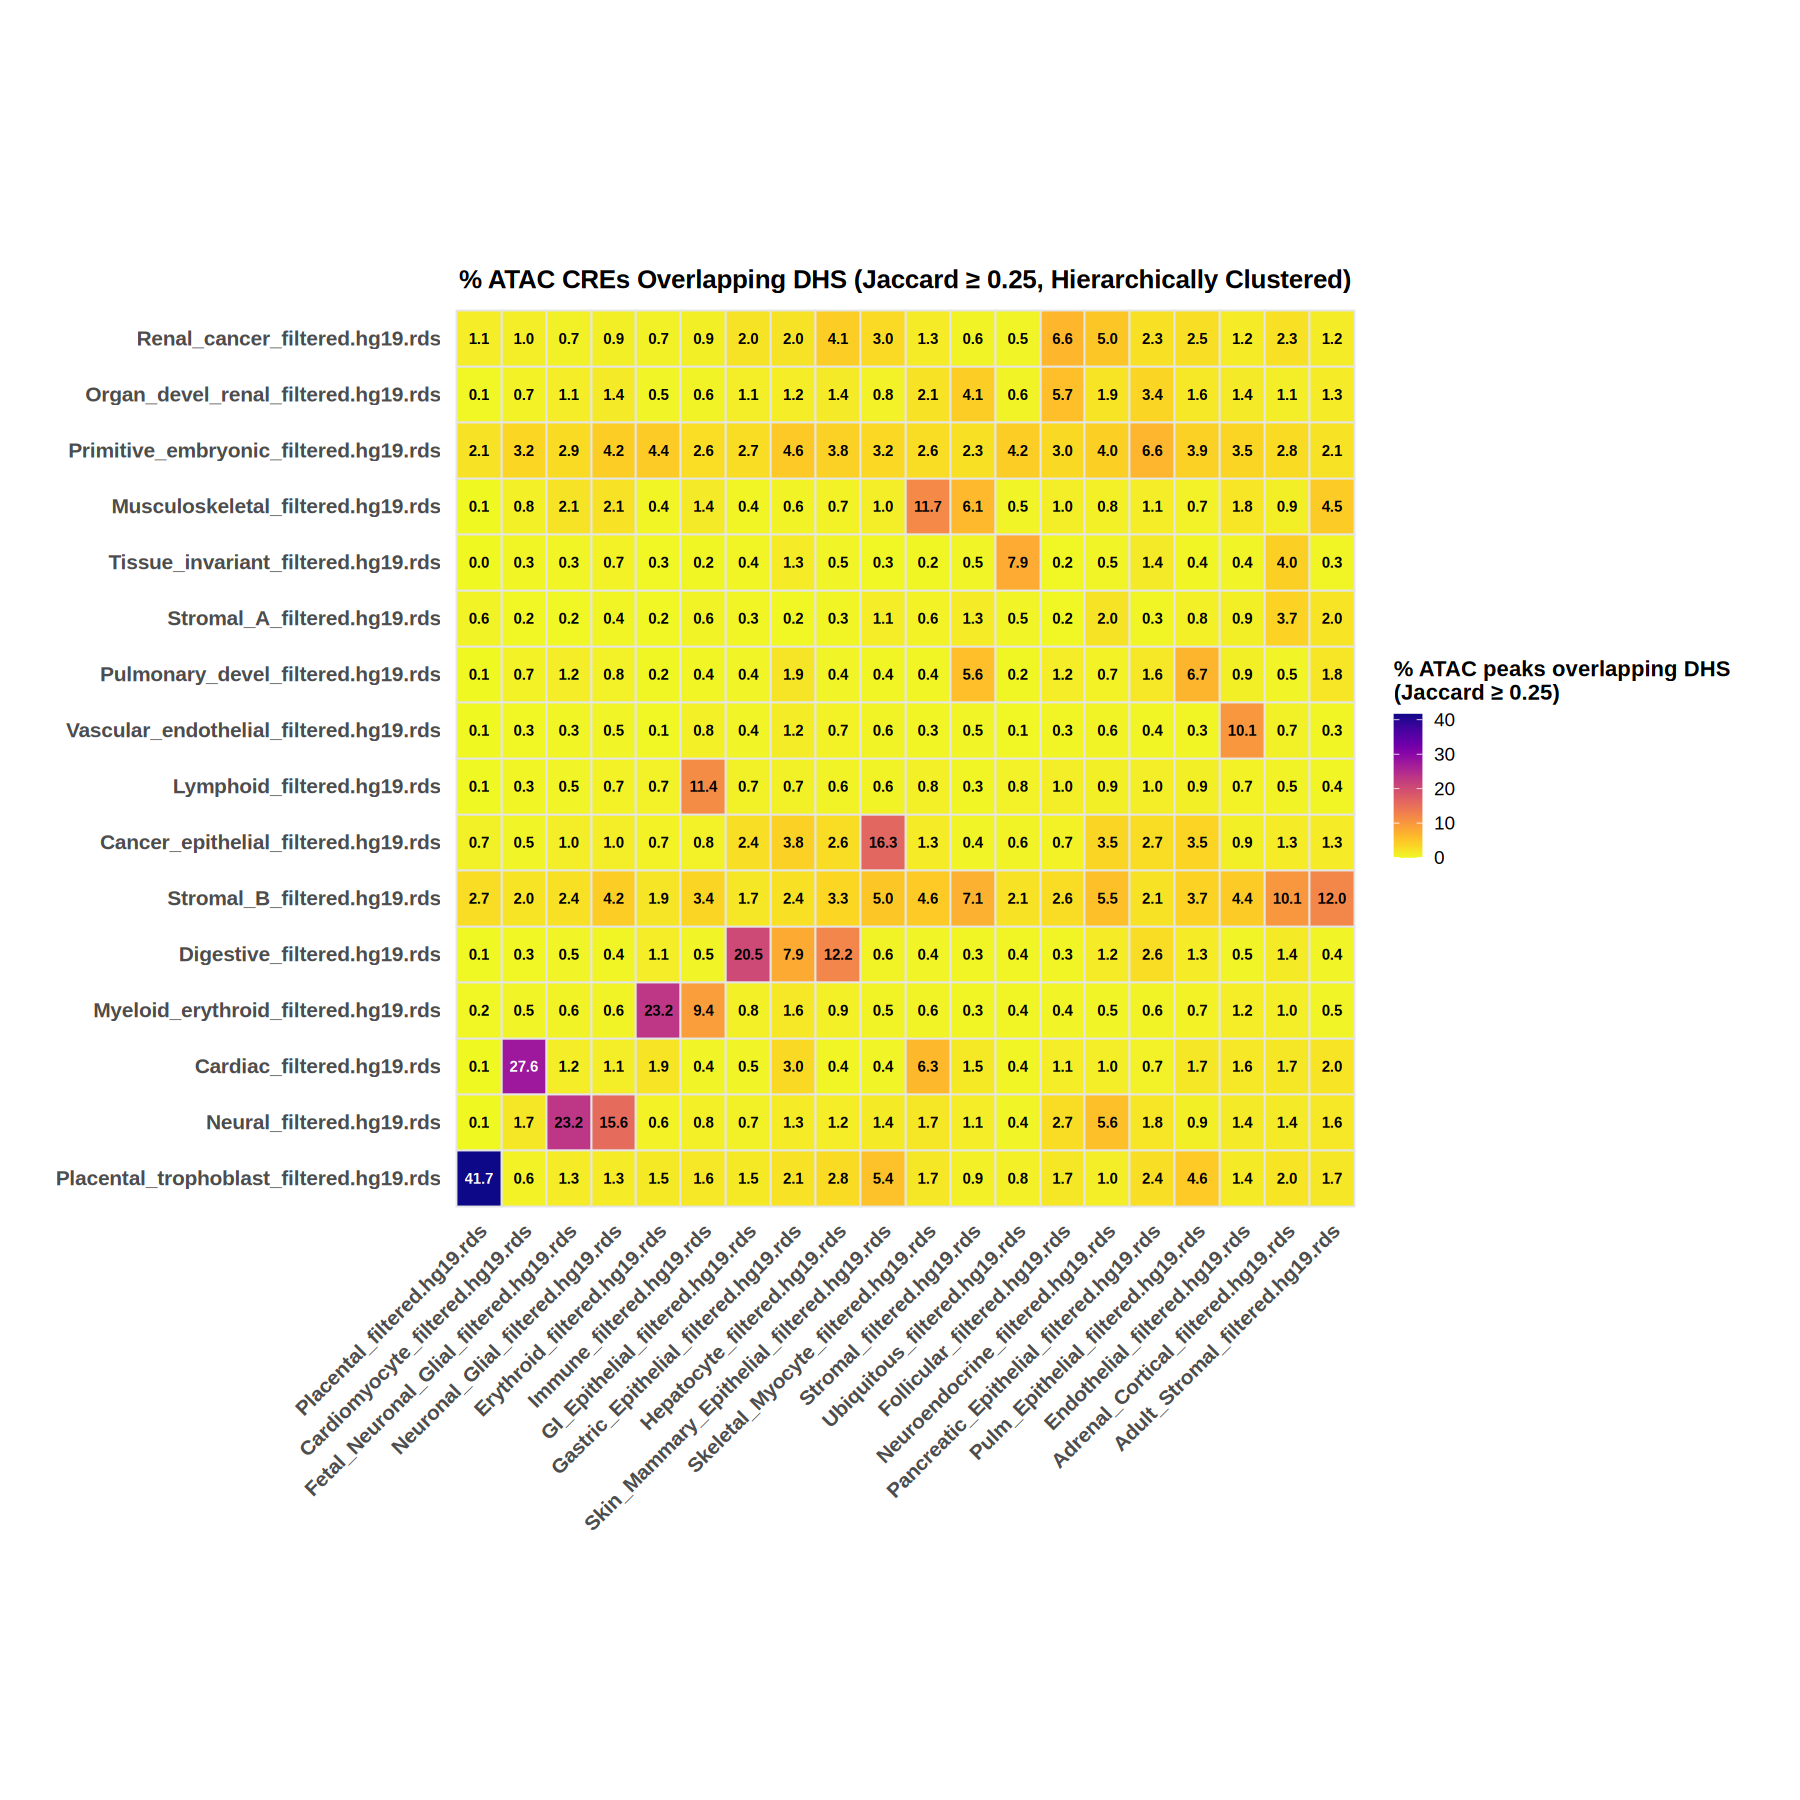

In [5]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – DHS–scATAC Overlap Heatmap (Jaccard ≥ 0.25)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
  library(fs)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
dhs_dir  <- "../ref/CRE_sites_Selective/DHS_sites_Selective3"
atac_dir <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
out_dir  <- "../ref/CRE_sites_Overlaps"
dir_create(out_dir)

out_png <- file.path(out_dir, "DHS_ATAC_overlap_heatmap_Jaccard25_clustered.png")

# ------------------------------------------------
# File lists
# ------------------------------------------------
dhs_files  <- list.files(dhs_dir,  pattern="\\.rds$", full.names=TRUE)
atac_files <- list.files(atac_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d DHS and %d ATAC selective files\n", length(dhs_files), length(atac_files)))

get_name <- function(path) gsub("_selective(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# Overlap function (Jaccard ≥ 0.25)
# ------------------------------------------------
compute_overlap_pct_jaccard <- function(gr_dhs, gr_atac, jaccard_threshold = 0.25) {
  hits <- findOverlaps(gr_dhs, gr_atac, ignore.strand = TRUE)
  if (length(hits) == 0) return(0)

  qh <- queryHits(hits)
  sh <- subjectHits(hits)
  ov <- pintersect(gr_dhs[qh], gr_atac[sh])

  w_ov    <- width(ov)
  w_union <- (pmax(end(gr_dhs[qh]), end(gr_atac[sh])) -
              pmin(start(gr_dhs[qh]), start(gr_atac[sh])) + 1L)
  jaccard <- w_ov / w_union

  keep <- jaccard >= jaccard_threshold
  if (!any(keep)) return(0)

  pct_atac <- 100 * length(unique(sh[keep])) / length(gr_atac)
  return(pct_atac)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(dhs_files)) {
  gr_dhs <- readRDS(dhs_files[i])
  dhs_name <- get_name(dhs_files[i])
  cat(sprintf("\nProcessing DHS: %s\n", dhs_name))

  for (j in seq_along(atac_files)) {
    gr_atac <- readRDS(atac_files[j])
    atac_name <- get_name(atac_files[j])
    pct <- compute_overlap_pct_jaccard(gr_dhs, gr_atac, jaccard_threshold = 0.25)
    overlap_dt <- rbind(
      overlap_dt,
      data.table(DHS = dhs_name, ATAC = atac_name, pct_overlap = pct)
    )
    cat(sprintf("  %s vs %s → %.2f%% of ATAC CREs (Jaccard≥0.25)\n", dhs_name, atac_name, pct))
  }
}

# ------------------------------------------------
# Build overlap matrix
# ------------------------------------------------
mat <- dcast(overlap_dt, DHS ~ ATAC, value.var = "pct_overlap", fill = 0)
row_names <- mat$DHS
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names

# ------------------------------------------------
# Hierarchical clustering
# ------------------------------------------------
row_order <- hclust(dist(mat_num))$order
col_order <- hclust(dist(t(mat_num)))$order

overlap_dt$DHS  <- factor(overlap_dt$DHS,  levels = row_names[row_order])
overlap_dt$ATAC <- factor(overlap_dt$ATAC, levels = colnames(mat_num)[col_order])

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / max(length(unique(overlap_dt$DHS)),
                                length(unique(overlap_dt$ATAC))))
overlap_dt$text_color <- ifelse(overlap_dt$pct_overlap > 25, "white", "black")

gf <- ggplot(overlap_dt, aes(x = ATAC, y = DHS, fill = pct_overlap)) +
  geom_tile(color = "grey90", linewidth = 0.4) +
  geom_text(aes(label = sprintf("%.1f", pct_overlap), color = text_color),
            size = tile_text_size, fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name = "% ATAC peaks overlapping DHS\n(Jaccard ≥ 0.25)",
    option = "C", direction = -1,
    limits = c(0, max(overlap_dt$pct_overlap, na.rm = TRUE)),
    breaks = pretty(c(0, max(overlap_dt$pct_overlap, na.rm = TRUE)), 5)
  ) +
  coord_fixed() +
  theme_minimal(base_size = 14) +
  theme(
    aspect.ratio = 1,
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1,
                               size = 12, face = "bold"),
    axis.text.y = element_text(size = 12, face = "bold"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 13),
    legend.text  = element_text(size = 11),
    plot.title   = element_text(face = "bold", size = 15, hjust = 0.5),
    plot.margin  = margin(20, 40, 20, 40)
  ) +
  ggtitle("% ATAC CREs Overlapping DHS (Jaccard ≥ 0.25, Hierarchically Clustered)")

# ------------------------------------------------
# Save and Display
# ------------------------------------------------
options(repr.plot.width = 15, repr.plot.height = 15)
print(gf)

ggsave(filename = out_png, plot = gf, width = 15, height = 15, dpi = 300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_png))


### Use Summit-based distances

Found 16 DHS and 20 ATAC selective files

Processing DHS: Cancer_epithelial_filtered.hg19.rds
  Cancer_epithelial_filtered.hg19.rds vs Adrenal_Cortical_filtered.hg19.rds → 0.75% of ATAC summits within ±50 bp
  Cancer_epithelial_filtered.hg19.rds vs Adult_Stromal_filtered.hg19.rds → 0.74% of ATAC summits within ±50 bp
  Cancer_epithelial_filtered.hg19.rds vs Cardiomyocyte_filtered.hg19.rds → 0.23% of ATAC summits within ±50 bp
  Cancer_epithelial_filtered.hg19.rds vs Endothelial_filtered.hg19.rds → 0.48% of ATAC summits within ±50 bp
  Cancer_epithelial_filtered.hg19.rds vs Erythroid_filtered.hg19.rds → 0.36% of ATAC summits within ±50 bp
  Cancer_epithelial_filtered.hg19.rds vs Fetal_Neuronal_Glial_filtered.hg19.rds → 0.56% of ATAC summits within ±50 bp
  Cancer_epithelial_filtered.hg19.rds vs Follicular_filtered.hg19.rds → 0.25% of ATAC summits within ±50 bp
  Cancer_epithelial_filtered.hg19.rds vs Gastric_Epithelial_filtered.hg19.rds → 2.24% of ATAC summits within ±50 bp
  Cancer_epi

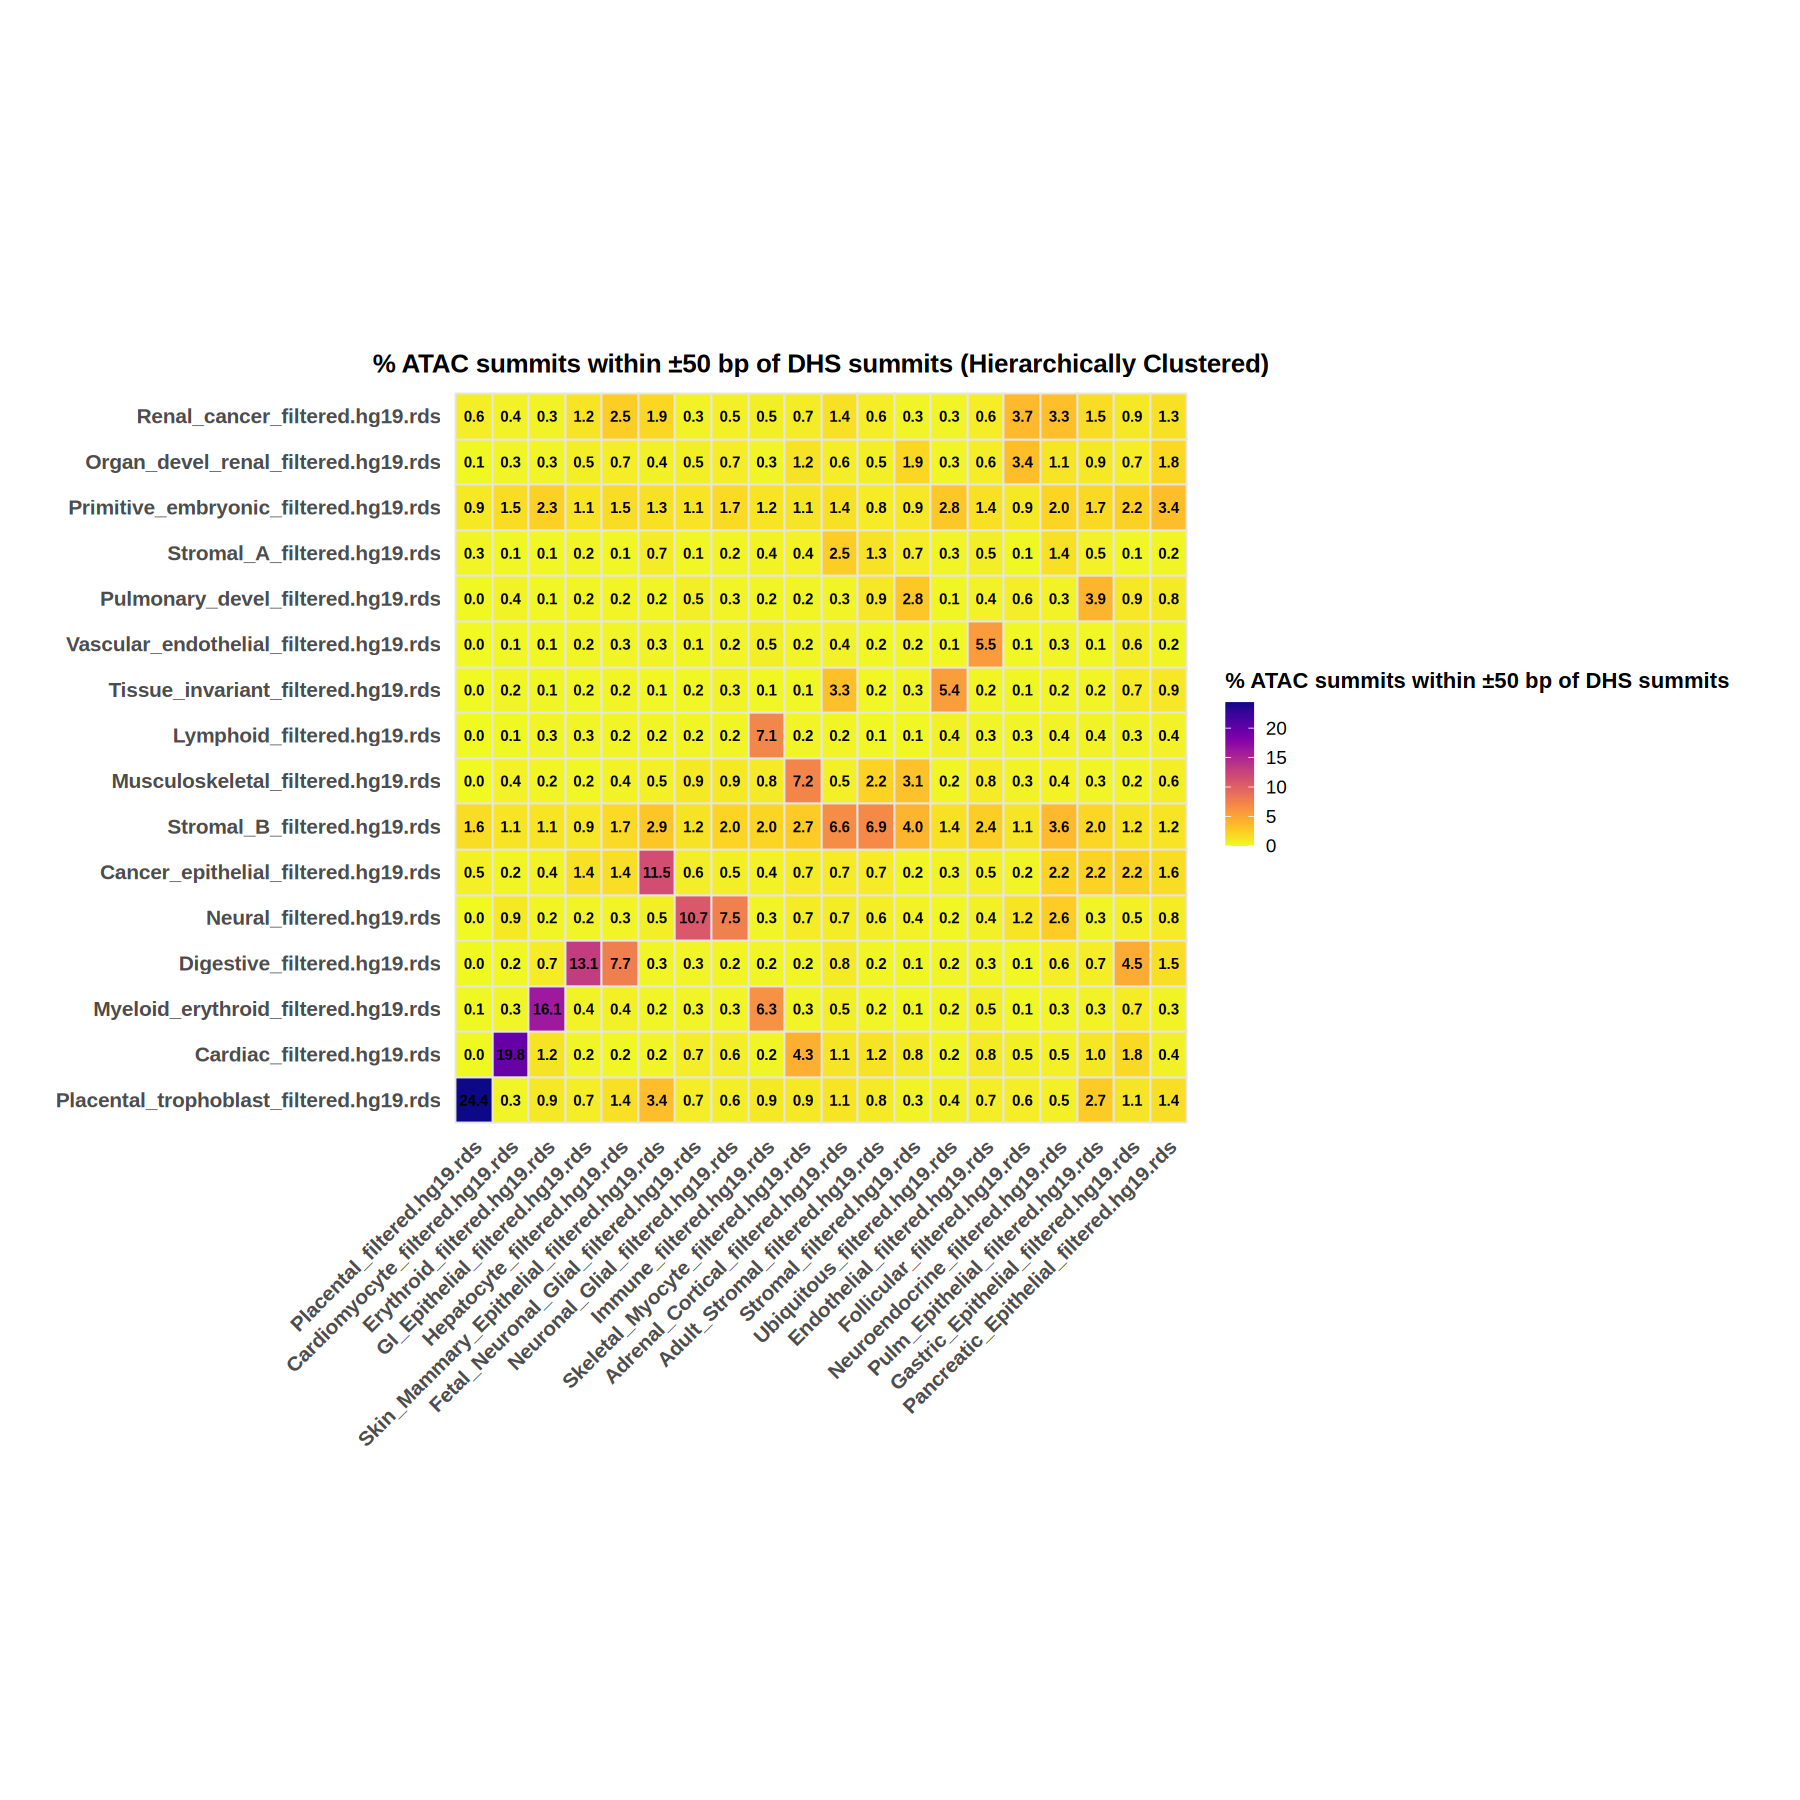

In [6]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – DHS–scATAC Overlap Heatmap (Summit Distance ≤ 50 bp)
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
  library(fs)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
dhs_dir  <- "../ref/CRE_sites_Selective/DHS_sites_Selective3"
atac_dir <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
out_dir  <- "../ref/CRE_sites_Overlaps"
dir_create(out_dir)

out_png <- file.path(out_dir, "DHS_ATAC_overlap_heatmap_summit25bp_clustered.png")

# ------------------------------------------------
# File lists
# ------------------------------------------------
dhs_files  <- list.files(dhs_dir,  pattern="\\.rds$", full.names=TRUE)
atac_files <- list.files(atac_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d DHS and %d ATAC selective files\n", length(dhs_files), length(atac_files)))

get_name <- function(path) gsub("_selective(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# Overlap function (Summit Distance ≤ 50 bp)
# ------------------------------------------------
compute_overlap_pct_summit <- function(gr_dhs, gr_atac,
                                       dhs_summit_col = "summit_hg19",
                                       atac_summit_col = "ATAC_summit_hg19",
                                       max_dist = 50) {

  # ---- Extract summits ----
  dhs_summit <- if (dhs_summit_col %in% names(mcols(gr_dhs))) {
    as.numeric(mcols(gr_dhs)[[dhs_summit_col]])
  } else {
    start(gr_dhs) + floor((width(gr_dhs) - 1L) / 2L)
  }

  atac_summit <- if (atac_summit_col %in% names(mcols(gr_atac))) {
    as.numeric(mcols(gr_atac)[[atac_summit_col]])
  } else {
    start(gr_atac) + floor((width(gr_atac) - 1L) / 2L)
  }

  # ---- Build GRanges of summits (1bp points) ----
  dhs_pts  <- GRanges(seqnames = seqnames(gr_dhs),
                      ranges   = IRanges(start = dhs_summit, end = dhs_summit),
                      strand   = "*")
  atac_pts <- GRanges(seqnames = seqnames(gr_atac),
                      ranges   = IRanges(start = atac_summit, end = atac_summit),
                      strand   = "*")

  # ---- Find pairs of summits within max_dist ----
  hits <- findOverlaps(dhs_pts, atac_pts, ignore.strand = TRUE, maxgap = max_dist)
  if (length(hits) == 0) return(0)

  # % of ATAC summits that have a DHS summit within ±max_dist
  pct_atac <- 100 * length(unique(subjectHits(hits))) / length(gr_atac)
  return(pct_atac)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(dhs_files)) {
  gr_dhs <- readRDS(dhs_files[i])
  dhs_name <- get_name(dhs_files[i])
  cat(sprintf("\nProcessing DHS: %s\n", dhs_name))

  for (j in seq_along(atac_files)) {
    gr_atac <- readRDS(atac_files[j])
    atac_name <- get_name(atac_files[j])

    pct <- compute_overlap_pct_summit(gr_dhs, gr_atac,
                                      dhs_summit_col = "summit_hg19",
                                      atac_summit_col = "ATAC_summit_hg19",
                                      max_dist = 25)
    overlap_dt <- rbind(
      overlap_dt,
      data.table(DHS = dhs_name, ATAC = atac_name, pct_overlap = pct)
    )

    cat(sprintf("  %s vs %s → %.2f%% of ATAC summits within ±50 bp\n",
                dhs_name, atac_name, pct))
  }
}

# ------------------------------------------------
# Build overlap matrix
# ------------------------------------------------
mat <- dcast(overlap_dt, DHS ~ ATAC, value.var = "pct_overlap", fill = 0)
row_names <- mat$DHS
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names

# ------------------------------------------------
# Hierarchical clustering
# ------------------------------------------------
row_order <- hclust(dist(mat_num))$order
col_order <- hclust(dist(t(mat_num)))$order

overlap_dt$DHS  <- factor(overlap_dt$DHS,  levels = row_names[row_order])
overlap_dt$ATAC <- factor(overlap_dt$ATAC, levels = colnames(mat_num)[col_order])

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / max(length(unique(overlap_dt$DHS)),
                                length(unique(overlap_dt$ATAC))))
overlap_dt$text_color <- ifelse(overlap_dt$pct_overlap > 25, "white", "black")

gf <- ggplot(overlap_dt, aes(x = ATAC, y = DHS, fill = pct_overlap)) +
  geom_tile(color = "grey90", linewidth = 0.4) +
  geom_text(aes(label = sprintf("%.1f", pct_overlap), color = text_color),
            size = tile_text_size, fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name = "% ATAC summits within ±50 bp of DHS summits",
    option = "C", direction = -1,
    limits = c(0, max(overlap_dt$pct_overlap, na.rm = TRUE)),
    breaks = pretty(c(0, max(overlap_dt$pct_overlap, na.rm = TRUE)), 5)
  ) +
  coord_fixed() +
  theme_minimal(base_size = 14) +
  theme(
    aspect.ratio = 1,
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1,
                               size = 12, face = "bold"),
    axis.text.y = element_text(size = 12, face = "bold"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 13),
    legend.text  = element_text(size = 11),
    plot.title   = element_text(face = "bold", size = 15, hjust = 0.5),
    plot.margin  = margin(20, 40, 20, 40)
  ) +
  ggtitle("% ATAC summits within ±50 bp of DHS summits (Hierarchically Clustered)")

# ------------------------------------------------
# Save and Display
# ------------------------------------------------
options(repr.plot.width = 15, repr.plot.height = 15)
print(gf)

ggsave(filename = out_png, plot = gf, width = 15, height = 15, dpi = 300)
cat(sprintf("\n✅ Heatmap saved to: %s\n", out_png))


### Two gates (Jaccard and summit BP filters)

Found 16 DHS and 20 ATAC selective files

Processing DHS: Cancer_epithelial_filtered.hg19.rds
  Cancer_epithelial_filtered.hg19.rds vs Adrenal_Cortical_filtered.hg19.rds → 0.72% (n=140 sites, Jaccard≥0.25 & Δ≤25bp)
  Cancer_epithelial_filtered.hg19.rds vs Adult_Stromal_filtered.hg19.rds → 0.71% (n=275 sites, Jaccard≥0.25 & Δ≤25bp)
  Cancer_epithelial_filtered.hg19.rds vs Cardiomyocyte_filtered.hg19.rds → 0.22% (n=24 sites, Jaccard≥0.25 & Δ≤25bp)
  Cancer_epithelial_filtered.hg19.rds vs Endothelial_filtered.hg19.rds → 0.47% (n=140 sites, Jaccard≥0.25 & Δ≤25bp)
  Cancer_epithelial_filtered.hg19.rds vs Erythroid_filtered.hg19.rds → 0.36% (n=38 sites, Jaccard≥0.25 & Δ≤25bp)
  Cancer_epithelial_filtered.hg19.rds vs Fetal_Neuronal_Glial_filtered.hg19.rds → 0.54% (n=425 sites, Jaccard≥0.25 & Δ≤25bp)
  Cancer_epithelial_filtered.hg19.rds vs Follicular_filtered.hg19.rds → 0.25% (n=14 sites, Jaccard≥0.25 & Δ≤25bp)
  Cancer_epithelial_filtered.hg19.rds vs Gastric_Epithelial_filtered.hg19.rds → 2.

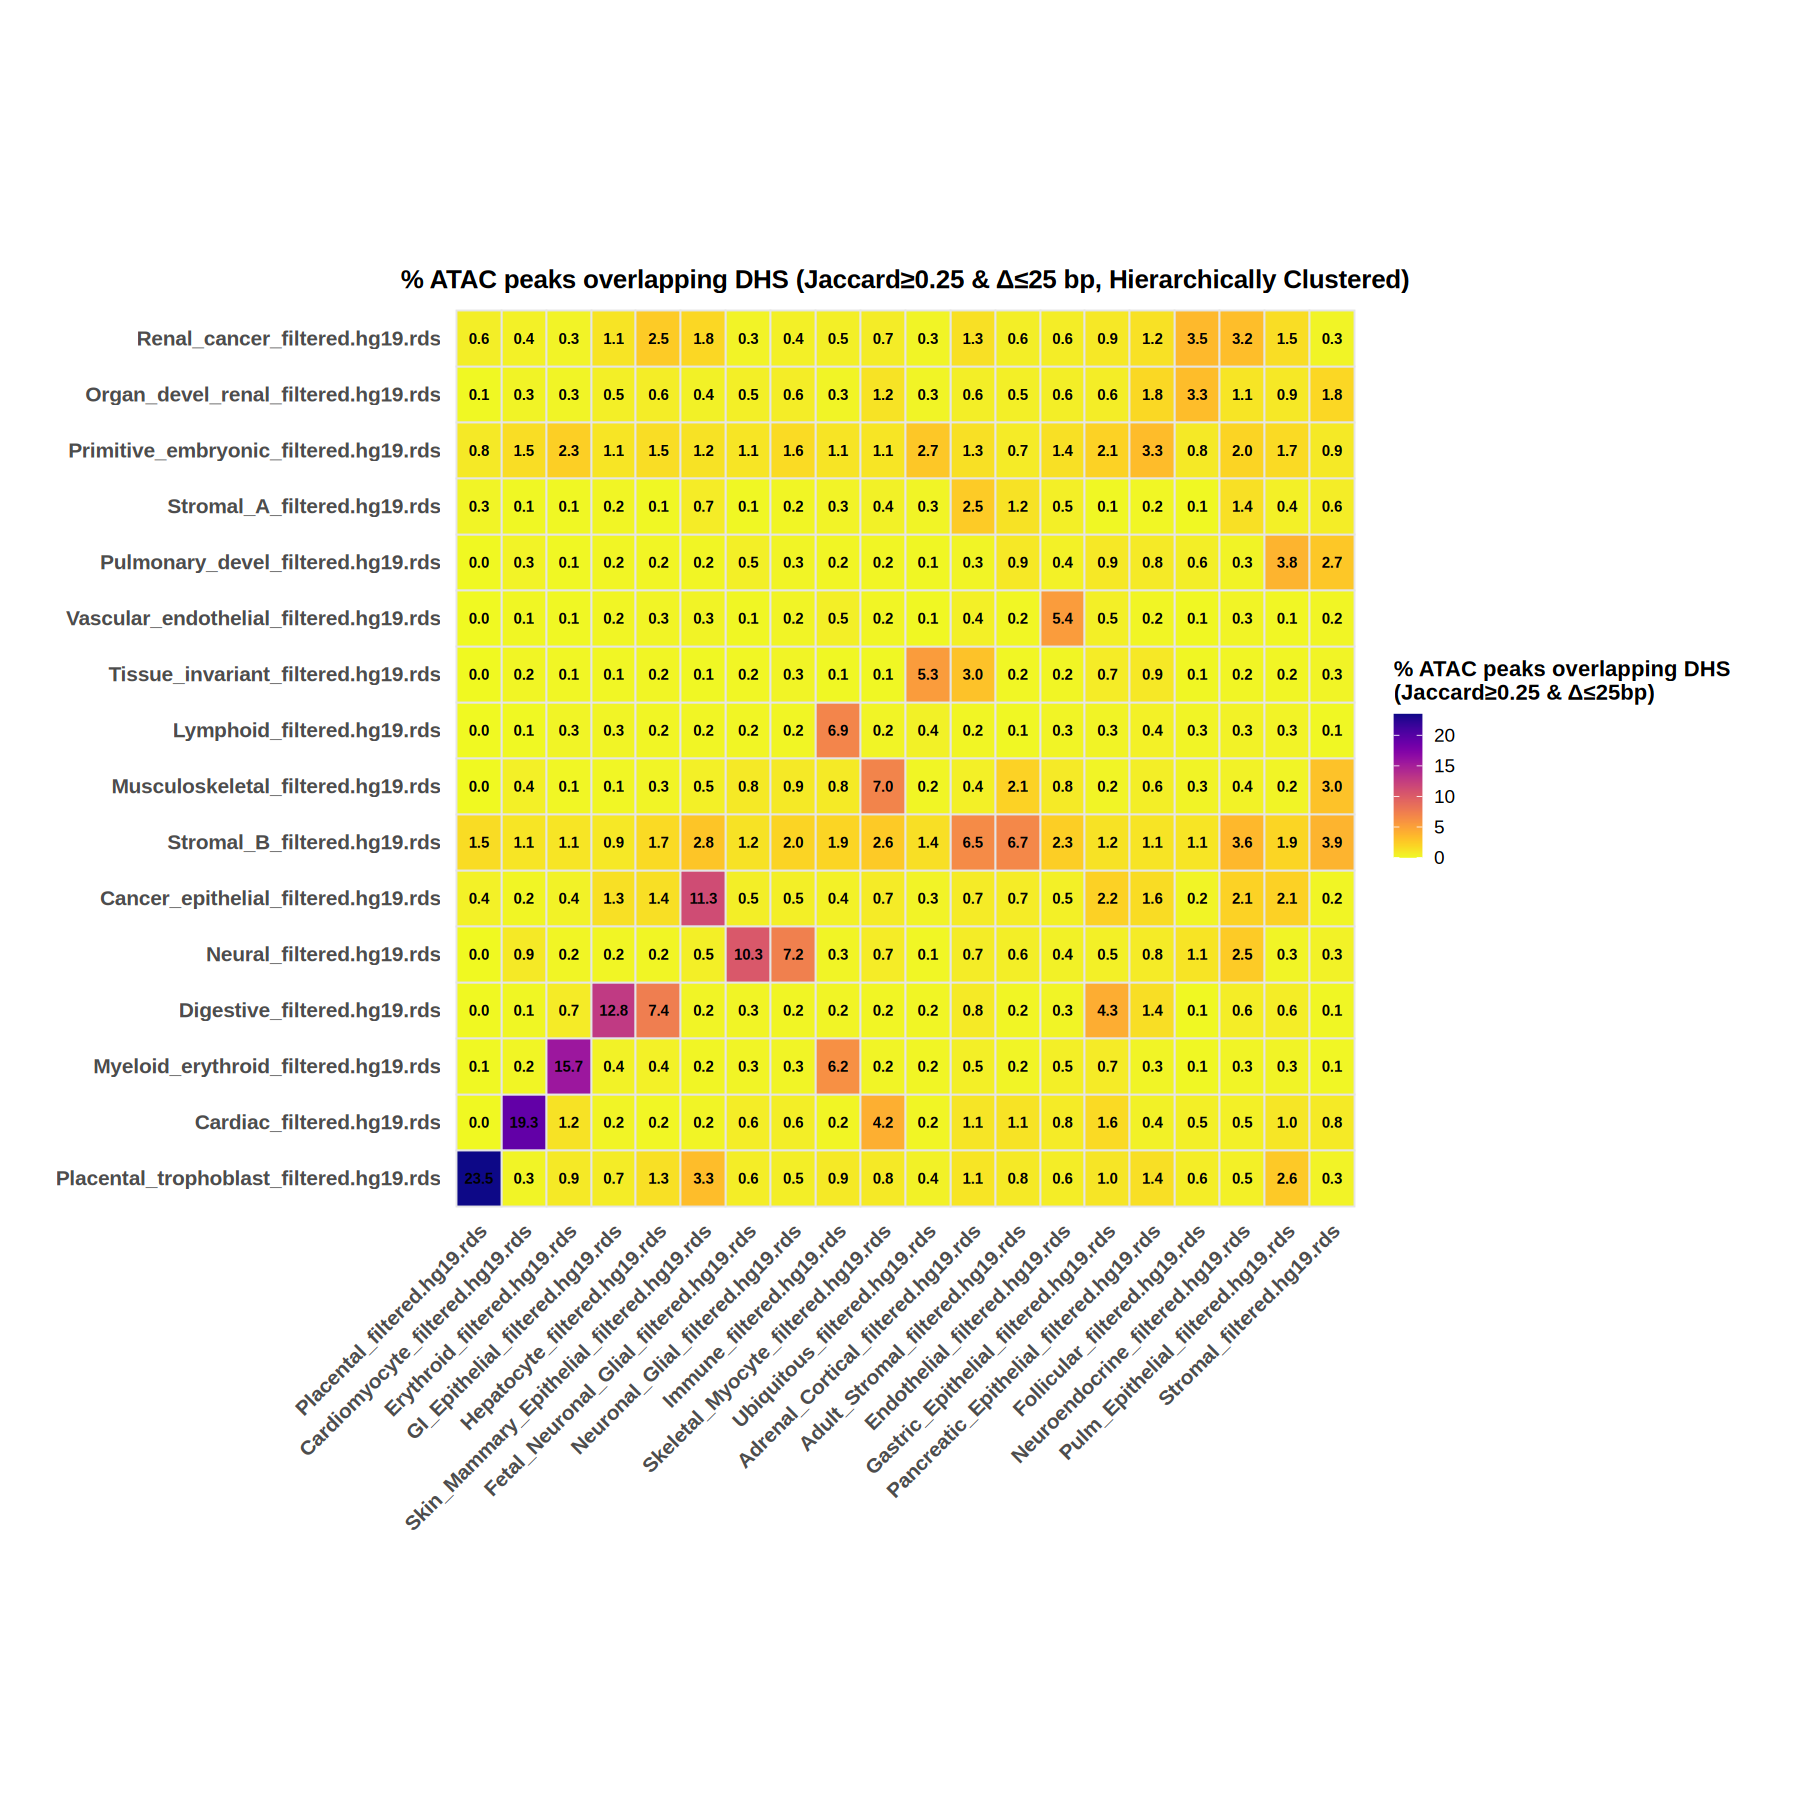

In [9]:
#!/usr/bin/env Rscript
# ===================================================================
# cfDNA CRE Reference – DHS–scATAC Overlap Heatmap
# Gates:  (1) Jaccard ≥ 0.25   AND   (2) |Δ summit| ≤ 25 bp
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
  library(fs)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
dhs_dir  <- "../ref/CRE_sites_Selective/DHS_sites_Selective3"
atac_dir <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
out_dir  <- "../ref/CRE_sites_Overlaps"
dir_create(out_dir)

out_png <- file.path(out_dir, "DHS_ATAC_overlap_heatmap_Jaccard25_summit25bp.png")
out_csv <- file.path(out_dir, "DHS_ATAC_overlap_summary_Jaccard25_summit25bp.csv")

# ------------------------------------------------
# Files
# ------------------------------------------------
dhs_files  <- list.files(dhs_dir,  pattern="\\.rds$", full.names=TRUE)
atac_files <- list.files(atac_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d DHS and %d ATAC selective files\n", length(dhs_files), length(atac_files)))

get_name <- function(path) gsub("_selective(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# Overlap function (two-gate rule)
# ------------------------------------------------
compute_overlap_pct_jaccard_summit <- function(gr_dhs, gr_atac,
                                               dhs_summit_col="summit_hg19",
                                               atac_summit_col="ATAC_summit_hg19",
                                               jaccard_threshold=0.25,
                                               summit_maxgap=25) {

  hits <- findOverlaps(gr_dhs, gr_atac, ignore.strand=TRUE)
  if (length(hits) == 0) return(list(pct=0, n_overlap=0))

  qh <- queryHits(hits); sh <- subjectHits(hits)
  ov <- pintersect(gr_dhs[qh], gr_atac[sh])

  # --- Jaccard filter ---
  w_ov    <- width(ov)
  w_union <- (pmax(end(gr_dhs[qh]), end(gr_atac[sh])) -
              pmin(start(gr_dhs[qh]), start(gr_atac[sh])) + 1L)
  jaccard <- w_ov / w_union
  keep_j <- jaccard >= jaccard_threshold
  if (!any(keep_j)) return(list(pct=0, n_overlap=0))

  qh <- qh[keep_j]; sh <- sh[keep_j]; ov <- ov[keep_j]

  # --- Summit filter (±25 bp) ---
  dhs_summit <- if (dhs_summit_col %in% names(mcols(gr_dhs))) {
    as.numeric(mcols(gr_dhs)[[dhs_summit_col]])
  } else start(gr_dhs) + floor((width(gr_dhs)-1L)/2L)

  atac_summit <- if (atac_summit_col %in% names(mcols(gr_atac))) {
    as.numeric(mcols(gr_atac)[[atac_summit_col]])
  } else start(gr_atac) + floor((width(gr_atac)-1L)/2L)

  delta <- abs(dhs_summit[qh] - atac_summit[sh])
  keep_s <- delta <= summit_maxgap
  if (!any(keep_s)) return(list(pct=0, n_overlap=0))

  qh <- qh[keep_s]; sh <- sh[keep_s]

  pct_atac <- 100 * length(unique(sh)) / length(gr_atac)
  n_overlap <- length(unique(sh))
  list(pct=pct_atac, n_overlap=n_overlap)
}

# ------------------------------------------------
# Compute all pairwise overlaps
# ------------------------------------------------
overlap_dt <- data.table()
for (i in seq_along(dhs_files)) {
  gr_dhs <- readRDS(dhs_files[i])
  dhs_name <- get_name(dhs_files[i])
  cat(sprintf("\nProcessing DHS: %s\n", dhs_name))

  for (j in seq_along(atac_files)) {
    gr_atac <- readRDS(atac_files[j])
    atac_name <- get_name(atac_files[j])

    res <- compute_overlap_pct_jaccard_summit(gr_dhs, gr_atac,
                                              jaccard_threshold=0.25,
                                              summit_maxgap=25)
    overlap_dt <- rbind(overlap_dt,
                        data.table(DHS=dhs_name,
                                   ATAC=atac_name,
                                   pct_overlap=res$pct,
                                   n_sites=res$n_overlap))
    cat(sprintf("  %s vs %s → %.2f%% (n=%d sites, Jaccard≥0.25 & Δ≤25bp)\n",
                dhs_name, atac_name, res$pct, res$n_overlap))
  }
}

# ------------------------------------------------
# Build matrix for heatmap (% overlap)
# ------------------------------------------------
mat <- dcast(overlap_dt, DHS ~ ATAC, value.var="pct_overlap", fill=0)
row_names <- mat$DHS
mat_num <- as.matrix(mat[, -1, with=FALSE])
rownames(mat_num) <- row_names

row_order <- hclust(dist(mat_num))$order
col_order <- hclust(dist(t(mat_num)))$order

overlap_dt$DHS  <- factor(overlap_dt$DHS,  levels=row_names[row_order])
overlap_dt$ATAC <- factor(overlap_dt$ATAC, levels=colnames(mat_num)[col_order])

# ------------------------------------------------
# BEAUTIFUL HEATMAP
# ------------------------------------------------
tile_text_size <- 6 * (10 / max(length(unique(overlap_dt$DHS)),
                                length(unique(overlap_dt$ATAC))))
overlap_dt$text_color <- ifelse(overlap_dt$pct_overlap > 25, "white", "black")

gf <- ggplot(overlap_dt, aes(x=ATAC, y=DHS, fill=pct_overlap)) +
  geom_tile(color="grey90", linewidth=0.4) +
  geom_text(aes(label=sprintf("%.1f", pct_overlap), color=text_color),
            size=tile_text_size, fontface="bold") +
  scale_color_identity() +
  scale_fill_viridis(
    name="% ATAC peaks overlapping DHS\n(Jaccard≥0.25 & Δ≤25bp)",
    option="C", direction=-1,
    limits=c(0, max(overlap_dt$pct_overlap, na.rm=TRUE)),
    breaks=pretty(c(0, max(overlap_dt$pct_overlap, na.rm=TRUE)), 5)
  ) +
  coord_fixed() +
  theme_minimal(base_size=14) +
  theme(
    aspect.ratio=1,
    axis.text.x=element_text(angle=45, hjust=1, vjust=1,
                             size=12, face="bold"),
    axis.text.y=element_text(size=12, face="bold"),
    axis.title=element_blank(),
    panel.grid=element_blank(),
    legend.position="right",
    legend.title=element_text(face="bold", size=13),
    legend.text=element_text(size=11),
    plot.title=element_text(face="bold", size=15, hjust=0.5),
    plot.margin=margin(20,40,20,40)
  ) +
  ggtitle("% ATAC peaks overlapping DHS (Jaccard≥0.25 & Δ≤25 bp, Hierarchically Clustered)")

options(repr.plot.width=15, repr.plot.height=15)
print(gf)

ggsave(filename=out_png, plot=gf, width=15, height=15, dpi=300)
fwrite(overlap_dt, out_csv)

cat(sprintf("\n✅ Heatmap saved: %s\n✅ CSV saved: %s\n", out_png, out_csv))


## Step 2: Filter for validated consensus overlapping CREs from DHS and ATAC seq assays

In [28]:
#!/usr/bin/env Rscript
# ================================================================
# DHS–ATAC Consensus Overlap Generator (Jaccard ≥ 0.25 & |Δsummit| ≤ 25 bp)
# Saves top DHS match per ATAC cell type (≥1000 sites)
# Retains full metadata including ATAC_summit_hg19
# ================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(fs)
})

# ------------------------------------------------
# 1. Paths and setup
# ------------------------------------------------
dhs_dir   <- "../ref/CRE_sites_Selective/DHS_sites_Selective3"
atac_dir  <- "../ref/CRE_sites_Selective/scATAC_sites_Selective3"
out_dir   <- "../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3"
stats_csv <- file.path(out_dir, "DHS_ATAC_overlap_summary_Jaccard25_summit25bp.csv")

dir_create(out_dir)
cat(sprintf("Output directory: %s\n", out_dir))

# ------------------------------------------------
# 2. File lists
# ------------------------------------------------
dhs_files  <- list.files(dhs_dir,  pattern="\\.rds$", full.names=TRUE)
atac_files <- list.files(atac_dir, pattern="\\.rds$", full.names=TRUE)
cat(sprintf("Found %d DHS and %d ATAC selective files\n",
            length(dhs_files), length(atac_files)))

get_name <- function(path) gsub("_selective(\\.hg19)?\\.rds$", "", basename(path))

# ------------------------------------------------
# 3. Overlap function (Jaccard ≥ 0.25 & summit ±25 bp)
# ------------------------------------------------
compute_overlap_consensus <- function(gr_dhs, gr_atac,
                                      dhs_summit_col="summit_hg19",
                                      atac_summit_col="ATAC_summit_hg19",
                                      jaccard_threshold=0.25,
                                      summit_window=25) {

  hits <- findOverlaps(gr_dhs, gr_atac, ignore.strand = TRUE)
  if (length(hits) == 0)
    return(list(pct = 0, gr = GRanges(), n_overlap = 0, qc = list()))

  qh <- queryHits(hits)
  sh <- subjectHits(hits)
  ov <- pintersect(gr_dhs[qh], gr_atac[sh])

  # --- Jaccard computation ---
  w_ov    <- width(ov)
  w_union <- (pmax(end(gr_dhs[qh]), end(gr_atac[sh])) -
              pmin(start(gr_dhs[qh]), start(gr_atac[sh])) + 1L)
  jaccard <- w_ov / w_union
  keep_j <- jaccard >= jaccard_threshold
  if (!any(keep_j))
    return(list(pct = 0, gr = GRanges(), n_overlap = 0, qc = list()))

  qh <- qh[keep_j]; sh <- sh[keep_j]; ov <- ov[keep_j]

  # --- Summit proximity filter ---
  dhs_summit <- if (dhs_summit_col %in% names(mcols(gr_dhs))) {
    as.numeric(mcols(gr_dhs)[[dhs_summit_col]])
  } else start(gr_dhs) + floor((width(gr_dhs)-1L)/2L)
  atac_summit <- if (atac_summit_col %in% names(mcols(gr_atac))) {
    as.numeric(mcols(gr_atac)[[atac_summit_col]])
  } else start(gr_atac) + floor((width(gr_atac)-1L)/2L)

  delta <- abs(dhs_summit[qh] - atac_summit[sh])
  keep_s <- delta <= summit_window
  if (!any(keep_s))
    return(list(pct = 0, gr = GRanges(), n_overlap = 0, qc = list()))

  qh <- qh[keep_s]; sh <- sh[keep_s]; ov <- ov[keep_s]

  # Prefix metadata
  dhs_hits  <- gr_dhs[qh]
  atac_hits <- gr_atac[sh]
  if (ncol(mcols(dhs_hits)) > 0)
    colnames(mcols(dhs_hits))  <- paste0("DHS_",  colnames(mcols(dhs_hits)))
  if (ncol(mcols(atac_hits)) > 0)
    colnames(mcols(atac_hits)) <- paste0("ATAC_", colnames(mcols(atac_hits)))

  # Preserve ATAC summit
  atac_summit_hg19 <- start(atac_hits) + floor((width(atac_hits) - 1L)/2L)
  mcols(atac_hits)$ATAC_summit_hg19 <- atac_summit_hg19
  mcols(atac_hits)$ATAC_summit_in_overlap <-
    atac_summit_hg19 >= start(ov) & atac_summit_hg19 <= end(ov)

  # Overlap metrics
  mcols(ov)$overlap_bp    <- w_ov[keep_j][keep_s]
  mcols(ov)$union_bp      <- w_union[keep_j][keep_s]
  mcols(ov)$jaccard_index <- round(jaccard[keep_j][keep_s], 3)
  mcols(ov)$summit_delta  <- delta[keep_s]

  # Merge metadata
  mcols(ov) <- cbind(mcols(ov), mcols(dhs_hits), mcols(atac_hits))

  pct <- 100 * length(unique(sh)) / length(gr_atac)

  qc <- list(
    n_DHS           = length(gr_dhs),
    n_ATAC          = length(gr_atac),
    n_overlap       = length(ov),
    pct_ATAC_in_DHS = round(pct, 3),
    median_width    = median(width(ov)),
    median_jaccard  = median(mcols(ov)$jaccard_index),
    median_delta    = median(mcols(ov)$summit_delta)
  )

  list(pct = pct, gr = ov, n_overlap = length(ov), qc = qc)
}

# ------------------------------------------------
# 4. Iterate over all DHS × ATAC combinations
# ------------------------------------------------
summary_dt <- data.table()

for (dhs_file in dhs_files) {
  gr_dhs <- readRDS(dhs_file)
  dhs_name <- get_name(dhs_file)
  cat(sprintf("\nProcessing DHS: %s\n", dhs_name))

  for (atac_file in atac_files) {
    gr_atac <- readRDS(atac_file)
    atac_name <- get_name(atac_file)

    overlap <- compute_overlap_consensus(gr_dhs, gr_atac,
                                         jaccard_threshold=0.25,
                                         summit_window=25)
    pct <- overlap$pct
    qc  <- overlap$qc

    summary_dt <- rbind(
      summary_dt,
      data.table(
        DHS = dhs_name,
        ATAC = atac_name,
        n_DHS = qc$n_DHS,
        n_ATAC = qc$n_ATAC,
        n_overlap = qc$n_overlap,
        pct_ATAC_in_DHS = qc$pct_ATAC_in_DHS,
        median_width = qc$median_width,
        median_jaccard = qc$median_jaccard,
        median_delta = qc$median_delta
      ),
      fill=TRUE
    )

    cat(sprintf("  %s-%s → %.2f%% (%d overlaps)\n",
                dhs_name, atac_name, pct, qc$n_overlap))
  }
}

# ------------------------------------------------
# 5. Save top DHS for each ATAC cell type (≥1000 sites)
# ------------------------------------------------
best_pairs <- summary_dt[n_overlap >= 1000]
best_pairs <- best_pairs[order(-pct_ATAC_in_DHS)]
best_pairs <- best_pairs[, .SD[1], by=ATAC]  # pick best DHS for each ATAC

cat(sprintf("\n✅ %d ATAC cell types meet ≥1000 site threshold.\n", nrow(best_pairs)))

for (k in seq_len(nrow(best_pairs))) {
  dhs_name  <- best_pairs$DHS[k]
  atac_name <- best_pairs$ATAC[k]

  gr_dhs  <- readRDS(file.path(dhs_dir,  paste0(dhs_name, "_selective.rds")))
  gr_atac <- readRDS(file.path(atac_dir, paste0(atac_name, "_selective.rds")))

  overlap <- compute_overlap_consensus(gr_dhs, gr_atac,
                                       jaccard_threshold=0.25,
                                       summit_window=25)
  if (overlap$n_overlap < 1000) next

  out_file <- file.path(out_dir, sprintf("%s-%s_overlap_hg19.rds", dhs_name, atac_name))
  saveRDS(overlap$gr, out_file)
  cat(sprintf("✅ SAVED %s (%d sites, %.2f%% overlap)\n",
              basename(out_file), overlap$n_overlap, overlap$pct))
}

# ------------------------------------------------
# 6. Save summary QC file
# ------------------------------------------------
fwrite(summary_dt[order(-pct_ATAC_in_DHS)], stats_csv)
cat(sprintf("\n📊 Summary QC file saved to: %s\n", stats_csv))
cat(sprintf("✅ Consensus .rds files written to: %s\n", out_dir))


Output directory: ../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3
Found 16 DHS and 20 ATAC selective files

Processing DHS: Cancer_epithelial_filtered.hg19.rds
  Cancer_epithelial_filtered.hg19.rds-Adrenal_Cortical_filtered.hg19.rds → 0.72% (140 overlaps)
  Cancer_epithelial_filtered.hg19.rds-Adult_Stromal_filtered.hg19.rds → 0.71% (275 overlaps)
  Cancer_epithelial_filtered.hg19.rds-Cardiomyocyte_filtered.hg19.rds → 0.22% (24 overlaps)
  Cancer_epithelial_filtered.hg19.rds-Endothelial_filtered.hg19.rds → 0.47% (140 overlaps)
  Cancer_epithelial_filtered.hg19.rds-Erythroid_filtered.hg19.rds → 0.36% (38 overlaps)
  Cancer_epithelial_filtered.hg19.rds-Fetal_Neuronal_Glial_filtered.hg19.rds → 0.54% (425 overlaps)
  Cancer_epithelial_filtered.hg19.rds-Follicular_filtered.hg19.rds → 0.25% (14 overlaps)
  Cancer_epithelial_filtered.hg19.rds-Gastric_Epithelial_filtered.hg19.rds → 2.17% (169 overlaps)
  Cancer_epithelial_filtered.hg19.rds-GI_Epithelial_filtered.hg19.rds → 1.35% (659 overl

## Quality Control of Overlap Files

In [18]:
#!/usr/bin/env Rscript
# ===================================================================
# Viz/QC for DHS–ATAC consensus overlaps (Jaccard≥0.25 & Δ≤25bp)
# Scans: ../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3/
# Outputs plots + a per-pair QC CSV
# ===================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
  library(ggplot2)
  library(viridis)
  library(dplyr)
  library(stringr)
  library(fs)
})

# ------------------------------------------------
# Paths
# ------------------------------------------------
overlap_dir <- "../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3"
qc_csv      <- file.path(overlap_dir, "DHS_ATAC_overlap_summary_Jaccard25_summit25bp.csv")
plot_dir    <- file.path(overlap_dir, "QC_plots")
dir_create(plot_dir)

# ------------------------------------------------
# Load summary CSV (global)
# ------------------------------------------------
qc_summary <- fread(qc_csv)

# ------------------------------------------------
# Helper: parse [DHS]-[ATAC]_overlap_hg19.rds
# ------------------------------------------------
parse_names <- function(fname_base) {
  # remove suffix
  core <- sub("_overlap_hg19\\.rds$", "", fname_base)
  # split first "-" into DHS and rest for ATAC (ATAC names can include hyphens)
  dash_pos <- regexpr("-", core, fixed = TRUE)
  dhs <- substr(core, 1, dash_pos - 1)
  atac <- substr(core, dash_pos + 1, nchar(core))
  data.frame(DHS = dhs, ATAC = atac, stringsAsFactors = FALSE)
}

# ------------------------------------------------
# Read all saved consensus GRanges
# ------------------------------------------------
rds_files <- dir(overlap_dir, pattern = "_overlap_hg19\\.rds$", full.names = TRUE)
stopifnot(length(rds_files) > 0)

message(sprintf("Found %d overlap .rds files to QC.", length(rds_files)))

pair_list <- vector("list", length(rds_files))
for (i in seq_along(rds_files)) {
  gr <- readRDS(rds_files[i])
  meta <- parse_names(basename(rds_files[i]))
  # Ensure expected columns exist (from our saving code)
  df <- as.data.frame(mcols(gr))
  if (!"jaccard_index" %in% names(df)) df$jaccard_index <- NA_real_
  if (!"summit_delta"  %in% names(df)) df$summit_delta  <- NA_real_
  pair_list[[i]] <- data.table(
    DHS  = meta$DHS,
    ATAC = meta$ATAC,
    width = width(gr),
    jaccard_index = df$jaccard_index,
    summit_delta  = df$summit_delta
  )
}
pairs_dt <- rbindlist(pair_list, use.names = TRUE, fill = TRUE)

# ------------------------------------------------
# Per-pair aggregated QC from GRanges contents
# ------------------------------------------------
agg_dt <- pairs_dt[, .(
  n_sites          = .N,
  median_width     = median(width, na.rm = TRUE),
  median_jaccard   = median(jaccard_index, na.rm = TRUE),
  median_delta_bp  = median(summit_delta, na.rm = TRUE)
), by = .(DHS, ATAC)]

# Join % overlap from global summary (pct_ATAC_in_DHS)
qc_keep <- qc_summary[, .(DHS, ATAC, pct_ATAC_in_DHS, n_overlap)]
agg_dt  <- agg_dt[qc_keep, on = c("DHS","ATAC")]

# Save aggregated QC table
qc_pairs_csv <- file.path(overlap_dir, "QC_pairs_aggregated.csv")
fwrite(agg_dt[order(-n_sites)], qc_pairs_csv)

# ------------------------------------------------
# (1) Barplot: #Consensus sites per ATAC cell type
# ------------------------------------------------
p_counts <- agg_dt %>%
  dplyr::select(ATAC, n_sites, pct_ATAC_in_DHS) %>%
  group_by(ATAC) %>%
  summarise(n_sites = max(n_sites, na.rm = TRUE),
            pct    = max(pct_ATAC_in_DHS, na.rm = TRUE),
            .groups = "drop") %>%
  ggplot(aes(x = reorder(ATAC, n_sites), y = n_sites, fill = pct)) +
  geom_col() +
  coord_flip() +
  scale_fill_viridis(option = "C", direction = -1, name = "% overlap") +
  labs(title = "Consensus CRE sites per ATAC cell type",
       x = "ATAC cell type", y = "# consensus sites") +
  theme_classic(base_size = 13)

ggsave(file.path(plot_dir, "bar_consensus_sites_per_ATAC.png"),
       p_counts, width = 9, height = 7, dpi = 300)

# ------------------------------------------------
# (2) Scatter: % overlap vs median Δsummit (precision vs recall)
# ------------------------------------------------
p_scatter <- agg_dt %>%
  dplyr::select(DHS, ATAC, pct_ATAC_in_DHS, median_delta_bp, n_sites) %>%
  ggplot(aes(x = median_delta_bp, y = pct_ATAC_in_DHS, size = n_sites)) +
  geom_point(alpha = 0.8) +
  scale_size_area(max_size = 10) +
  labs(title = "% overlap vs median |Δ summit|",
       x = "Median |Δ summit| (bp)",
       y = "% ATAC peaks overlapping DHS (dual-gated)") +
  theme_classic(base_size = 13)

ggsave(file.path(plot_dir, "scatter_pct_vs_medianDelta.png"),
       p_scatter, width = 7.5, height = 5.5, dpi = 300)

# ------------------------------------------------
# (3) Violin: Jaccard distribution for top 10 pairs by n_sites
# ------------------------------------------------
top10_pairs <- agg_dt[order(-n_sites)][1:min(10, .N), .(DHS, ATAC)]
pairs_dt_top <- pairs_dt[top10_pairs, on = c("DHS","ATAC")]

p_violin_j <- pairs_dt_top %>%
  mutate(pair = paste0(DHS, " – ", ATAC)) %>%
  ggplot(aes(x = reorder(pair, -width), y = jaccard_index)) +
  geom_violin(fill = "grey85", color = "grey40") +
  stat_summary(fun = median, geom = "point", size = 1.7) +
  coord_flip() +
  labs(title = "Jaccard distribution (top 10 pairs by site count)",
       x = "Pair (DHS – ATAC)", y = "Jaccard index") +
  theme_classic(base_size = 12)

ggsave(file.path(plot_dir, "violin_jaccard_top10.png"),
       p_violin_j, width = 9.5, height = 6.5, dpi = 300)

# ------------------------------------------------
# (4) Histograms of overlap widths for top 6 pairs
# ------------------------------------------------
top6_pairs <- agg_dt[order(-n_sites)][1:min(6, .N), .(DHS, ATAC)]
pairs_dt_top6 <- pairs_dt[top6_pairs, on = c("DHS","ATAC")] %>%
  mutate(pair = paste0(DHS, " – ", ATAC))

p_widths <- ggplot(pairs_dt_top6, aes(x = width)) +
  geom_histogram(bins = 60, fill = "steelblue", color = "white") +
  facet_wrap(~ pair, scales = "free_y", ncol = 2) +
  labs(title = "Overlap (intersection) width distributions – top 6 pairs",
       x = "Overlap width (bp)", y = "Count") +
  theme_classic(base_size = 12)

ggsave(file.path(plot_dir, "hist_widths_top6.png"),
       p_widths, width = 10, height = 7, dpi = 300)

# ------------------------------------------------
# (5) Heatmap of % overlap for the saved best pairs
# ------------------------------------------------
heat_dt <- agg_dt %>%
  dplyr::select(DHS, ATAC, pct_ATAC_in_DHS, n_sites)

if (nrow(heat_dt) > 1) {
  # order axes by clustering on matrix (optional quick hclust)
  mat <- xtabs(pct_ATAC_in_DHS ~ DHS + ATAC, data = heat_dt)
  if (nrow(mat) > 1 && ncol(mat) > 1) {
    row_ord <- hclust(dist(mat))$order
    col_ord <- hclust(dist(t(mat)))$order
    DHS_levels  <- rownames(mat)[row_ord]
    ATAC_levels <- colnames(mat)[col_ord]
    heat_dt <- heat_dt %>%
      mutate(DHS  = factor(DHS,  levels = DHS_levels),
             ATAC = factor(ATAC, levels = ATAC_levels))
  }
  p_heat <- ggplot(heat_dt, aes(x = ATAC, y = DHS, fill = pct_ATAC_in_DHS)) +
    geom_tile(color = "grey90") +
    geom_text(aes(label = sprintf("%.1f", pct_ATAC_in_DHS)), size = 3) +
    scale_fill_viridis(option = "C", direction = -1, name = "% overlap") +
    theme_minimal(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) +
    labs(title = "Saved best pairs: % overlap (dual-gated)",
         x = "ATAC cell type", y = "DHS tissue")
  ggsave(file.path(plot_dir, "heatmap_pct_overlap_saved_pairs.png"),
         p_heat, width = 10, height = 7, dpi = 300)
}

cat("\n✅ QC complete.\n")
cat(sprintf("• Aggregated pair metrics: %s\n", qc_pairs_csv))
cat(sprintf("• Plots written to: %s\n", plot_dir))


Found 15 overlap .rds files to QC.

Warning message:
“There were 5 warnings in `summarise()`.
The first warning was:
ℹ In argument: `n_sites = max(n_sites, na.rm = TRUE)`.
ℹ In group 7: `ATAC = "Follicular_filtered.hg19.rds"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings.”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_col()`).”
Warning message:
“Removed 305 rows containing missing values or values outside the scale range (`geom_point()`).”



✅ QC complete.
• Aggregated pair metrics: ../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3/QC_pairs_aggregated.csv
• Plots written to: ../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3/QC_plots


### Cleaning names 

In [29]:
# ================================================================
# Normalize consensus overlap filenames
# From: <DHS>_filtered.hg19.rds-<ATAC>_filtered.hg19.rds_overlap_hg19.rds
#   To: <DHS>-<ATAC>.hg19.consensus.overlaps.rds
# ================================================================

# install.packages("fs")  # if needed
library(fs)

overlap_dir <- "../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3"

# Match your current filenames exactly
files <- dir(overlap_dir, pattern = "_overlap_hg19\\.rds$", full.names = TRUE)
cat(sprintf("Found %d files to rename\n", length(files)))

clean_one <- function(fullpath) {
  nm <- basename(fullpath)

  # 1) Strip the tail
  core <- sub("_overlap_hg19\\.rds$", "", nm)

  # 2) Split DHS vs ATAC at the ".rds-" boundary (safe if names contain hyphens)
  split_pos <- regexpr("\\.rds-", core)
  if (split_pos == -1) {
    warning(sprintf("Skipping (cannot find '.rds-' split): %s", nm))
    return(NA_character_)
  }

  dhs_part  <- substr(core, 1, split_pos + 3)           # includes ".rds"
  atac_part <- substr(core, split_pos + 5, nchar(core)) # after ".rds-"

  # 3) Remove "_filtered.hg19.rds" from each side
  dhs_clean  <- sub("_filtered\\.hg19\\.rds$", "", dhs_part)
  atac_clean <- sub("_filtered\\.hg19\\.rds$", "", atac_part)

  # 4) Build the new name
  new_nm <- sprintf("%s-%s.hg19.consensus.overlaps.rds", dhs_clean, atac_clean)
  file.path(dirname(fullpath), new_nm)
}

new_files <- vapply(files, clean_one, character(1))
keep <- !is.na(new_files)

# Preview plan
if (any(keep)) {
  print(data.frame(old = basename(files[keep]), new = basename(new_files[keep])))
} else {
  cat("No files matched for renaming.\n")
}

# Rename (skip if already the same)
to_move <- files[keep & basename(files) != basename(new_files)]
dest    <- new_files[keep & basename(files) != basename(new_files)]

if (length(to_move)) {
  fs::file_move(to_move, dest)
  cat(sprintf("✅ Renamed %d files.\n", length(to_move)))
} else {
  cat("No files needed renaming (names already normalized).\n")
}


Found 15 files to rename
                                                                                              old
1  Cancer_epithelial_filtered.hg19.rds-Skin_Mammary_Epithelial_filtered.hg19.rds_overlap_hg19.rds
2                      Cardiac_filtered.hg19.rds-Cardiomyocyte_filtered.hg19.rds_overlap_hg19.rds
3                    Digestive_filtered.hg19.rds-GI_Epithelial_filtered.hg19.rds_overlap_hg19.rds
4                            Lymphoid_filtered.hg19.rds-Immune_filtered.hg19.rds_overlap_hg19.rds
5           Musculoskeletal_filtered.hg19.rds-Skeletal_Myocyte_filtered.hg19.rds_overlap_hg19.rds
6                Myeloid_erythroid_filtered.hg19.rds-Erythroid_filtered.hg19.rds_overlap_hg19.rds
7                Neural_filtered.hg19.rds-Fetal_Neuronal_Glial_filtered.hg19.rds_overlap_hg19.rds
8                      Neural_filtered.hg19.rds-Neuronal_Glial_filtered.hg19.rds_overlap_hg19.rds
9            Placental_trophoblast_filtered.hg19.rds-Placental_filtered.hg19.rds_overlap_hg19

✅ Loaded: Cancer_epithelial-Skin_Mammary_Epithelial.hg19.consensus.overlaps.rds
   Total consensus sites: 3151

GRanges object with 3151 ranges and 48 metadata columns:
         seqnames            ranges strand | summit_hg19 core_start_hg19
            <Rle>         <IRanges>  <Rle> |   <integer>       <integer>
     [1]     chr1   2359959-2360179      * |     2360069         2360055
     [2]     chr1   5961320-5961500      * |     5961410         5961390
     [3]     chr1   6361675-6361900      * |     6361790         6361750
     [4]     chr1   6924840-6925020      * |     6924930         6924930
     [5]     chr1   8095440-8095629      * |     8095550         8095475
     ...      ...               ...    ... .         ...             ...
  [3147]     chrY 18088720-18088940      * |    18088830        18088814
  [3148]     chrY 18094060-18094220      * |    18094140        18094130
  [3149]     chrY 19150420-19150620      * |    19150510        19150494
  [3150]     chrY 21206806-2

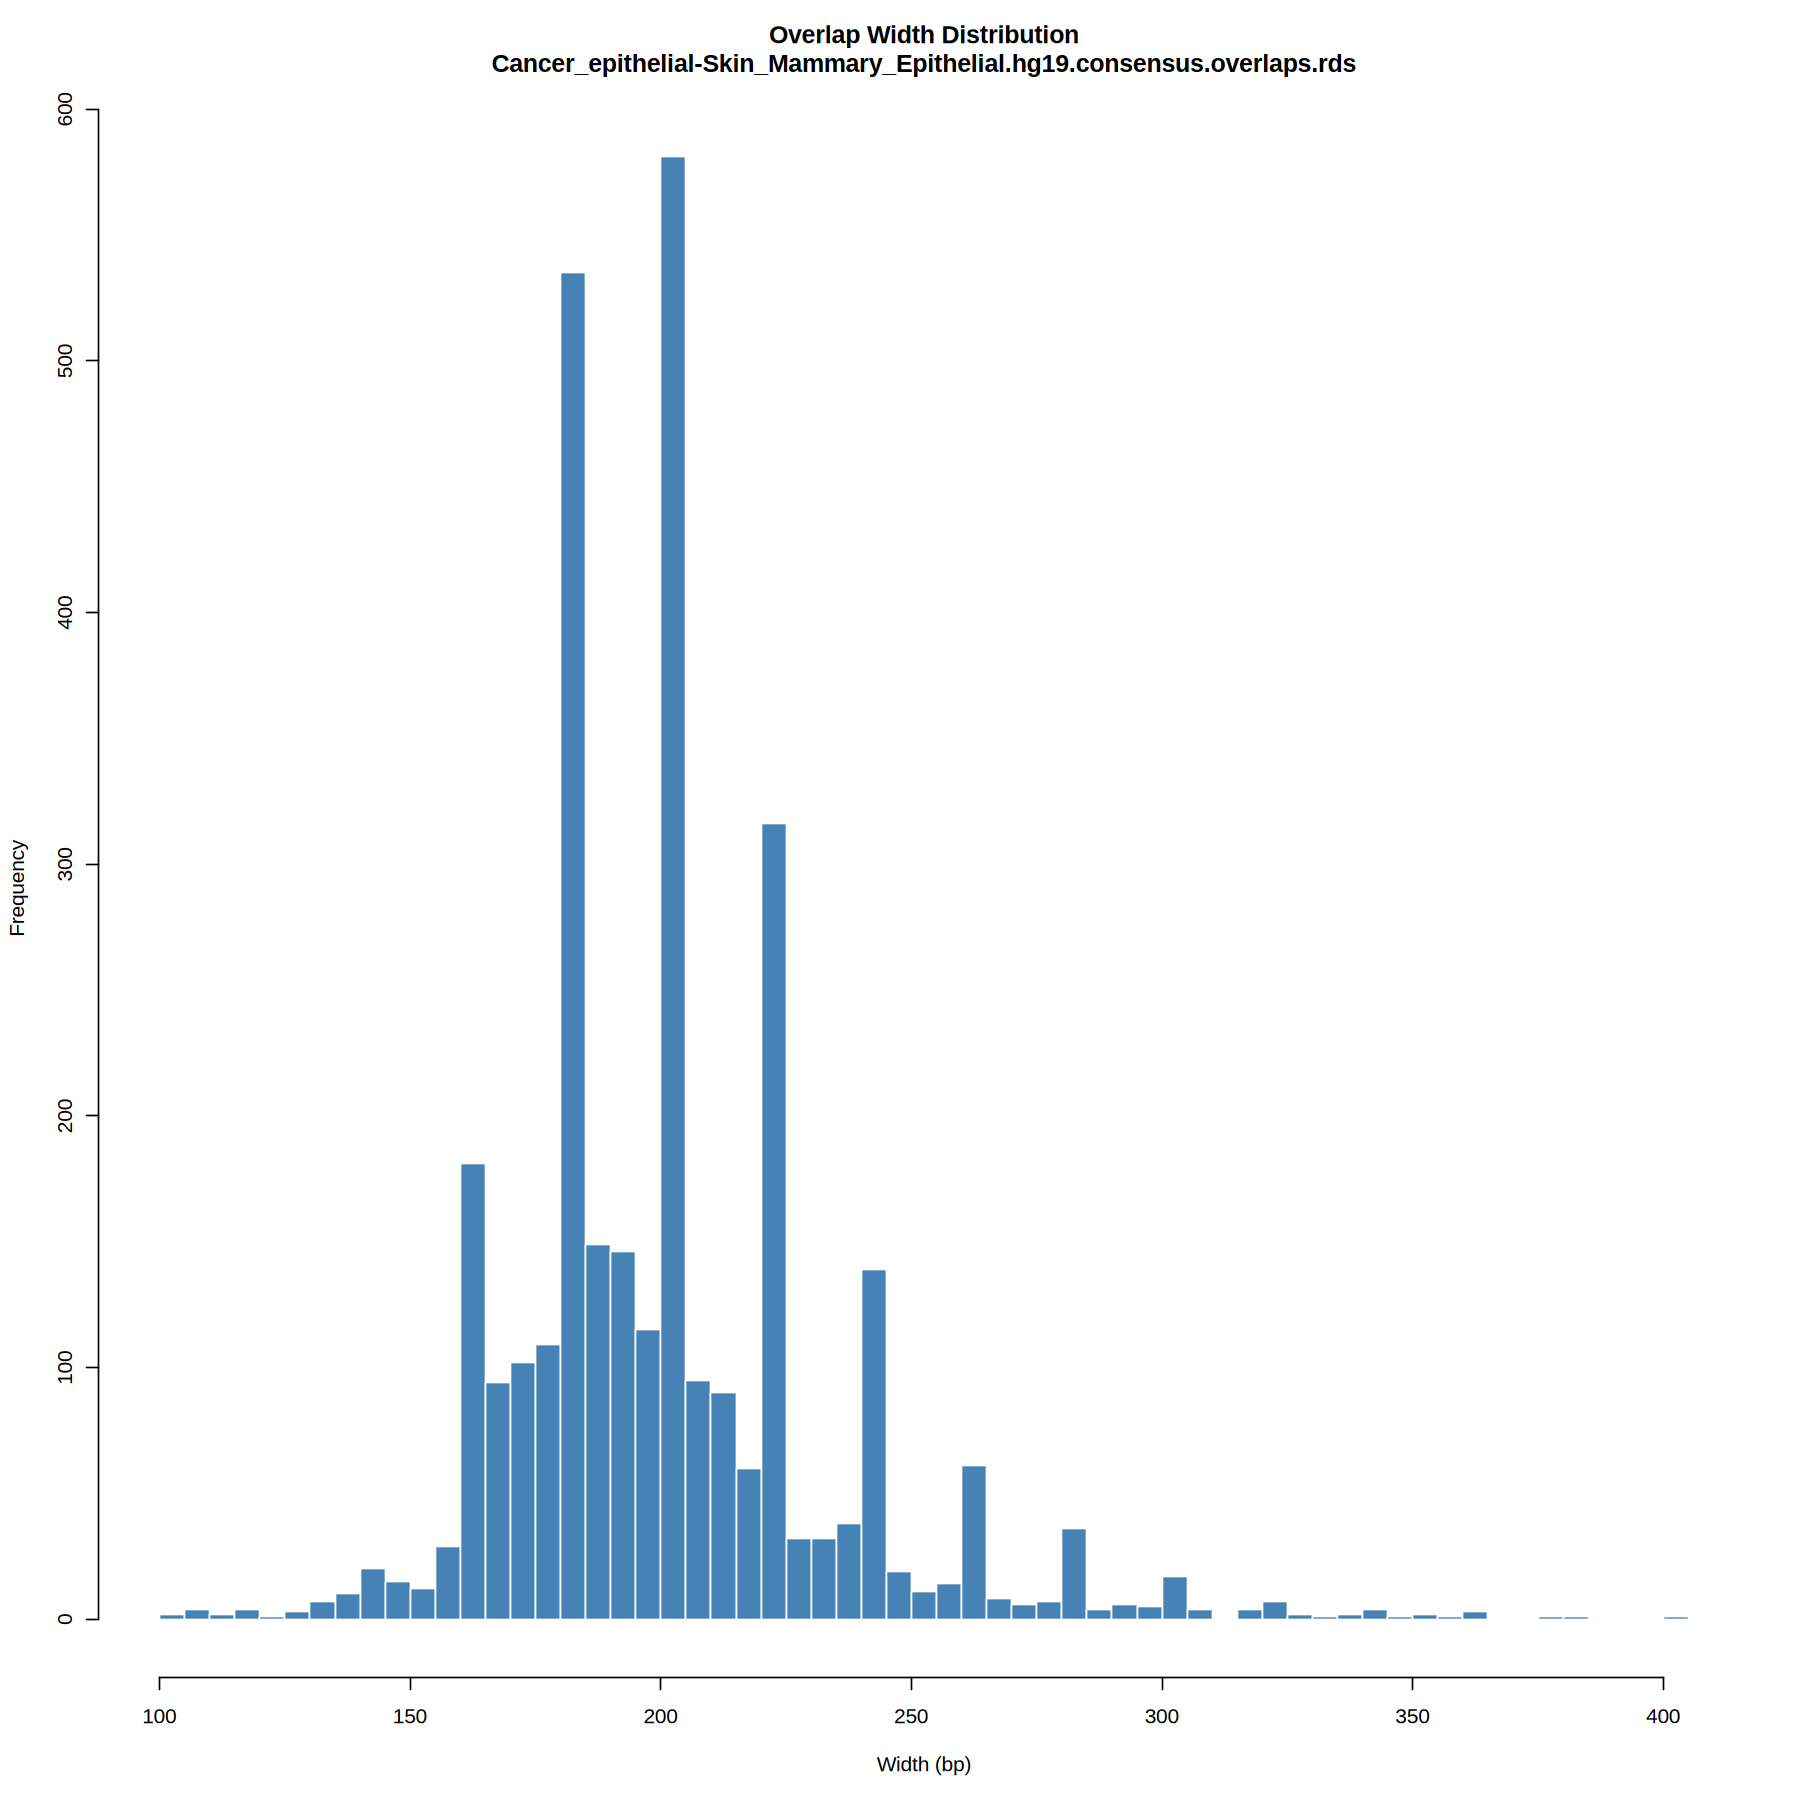

In [24]:
# ================================================================
# Inspect one cleaned consensus overlap file
# ================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(data.table)
})

# ------------------------------------------------
# Path and file to inspect
# ------------------------------------------------
overlap_dir <- "../ref/CRE_sites_Overlaps/DHS_ATAC_jaccard_overlaps3"
file_to_load <- file.path(overlap_dir,
                          "Cancer_epithelial-Skin_Mammary_Epithelial.hg19.consensus.overlaps.rds")

# ------------------------------------------------
# Load file
# ------------------------------------------------
gr <- readRDS(file_to_load)
cat(sprintf("✅ Loaded: %s\n", basename(file_to_load)))
cat(sprintf("   Total consensus sites: %d\n\n", length(gr)))

# ------------------------------------------------
# View structure and first few ranges
# ------------------------------------------------
print(gr)
cat("\nFirst 5 coordinates:\n")
print(as.data.frame(gr)[1:5, c("seqnames", "start", "end")])

cat("\nMetadata columns:\n")
print(colnames(mcols(gr)))

# ------------------------------------------------
# QC summaries
# ------------------------------------------------
cat("\nWidth stats:\n")
cat(sprintf("  Median width : %.1f bp\n", median(width(gr))))
cat(sprintf("  Mean width   : %.1f bp\n", mean(width(gr))))
cat(sprintf("  Total span   : %.0f bp\n", sum(width(gr))))

if (all(c("jaccard_index", "summit_delta") %in% colnames(mcols(gr)))) {
  cat("\nJaccard summary:\n")
  print(summary(mcols(gr)$jaccard_index))
  cat("\nSummit Δ (bp) summary:\n")
  print(summary(mcols(gr)$summit_delta))
}

# ------------------------------------------------
# Optional histogram
# ------------------------------------------------
hist(width(gr),
     breaks = 50,
     col = "steelblue",
     main = sprintf("Overlap Width Distribution\n%s", basename(file_to_load)),
     xlab = "Width (bp)",
     border = "white")


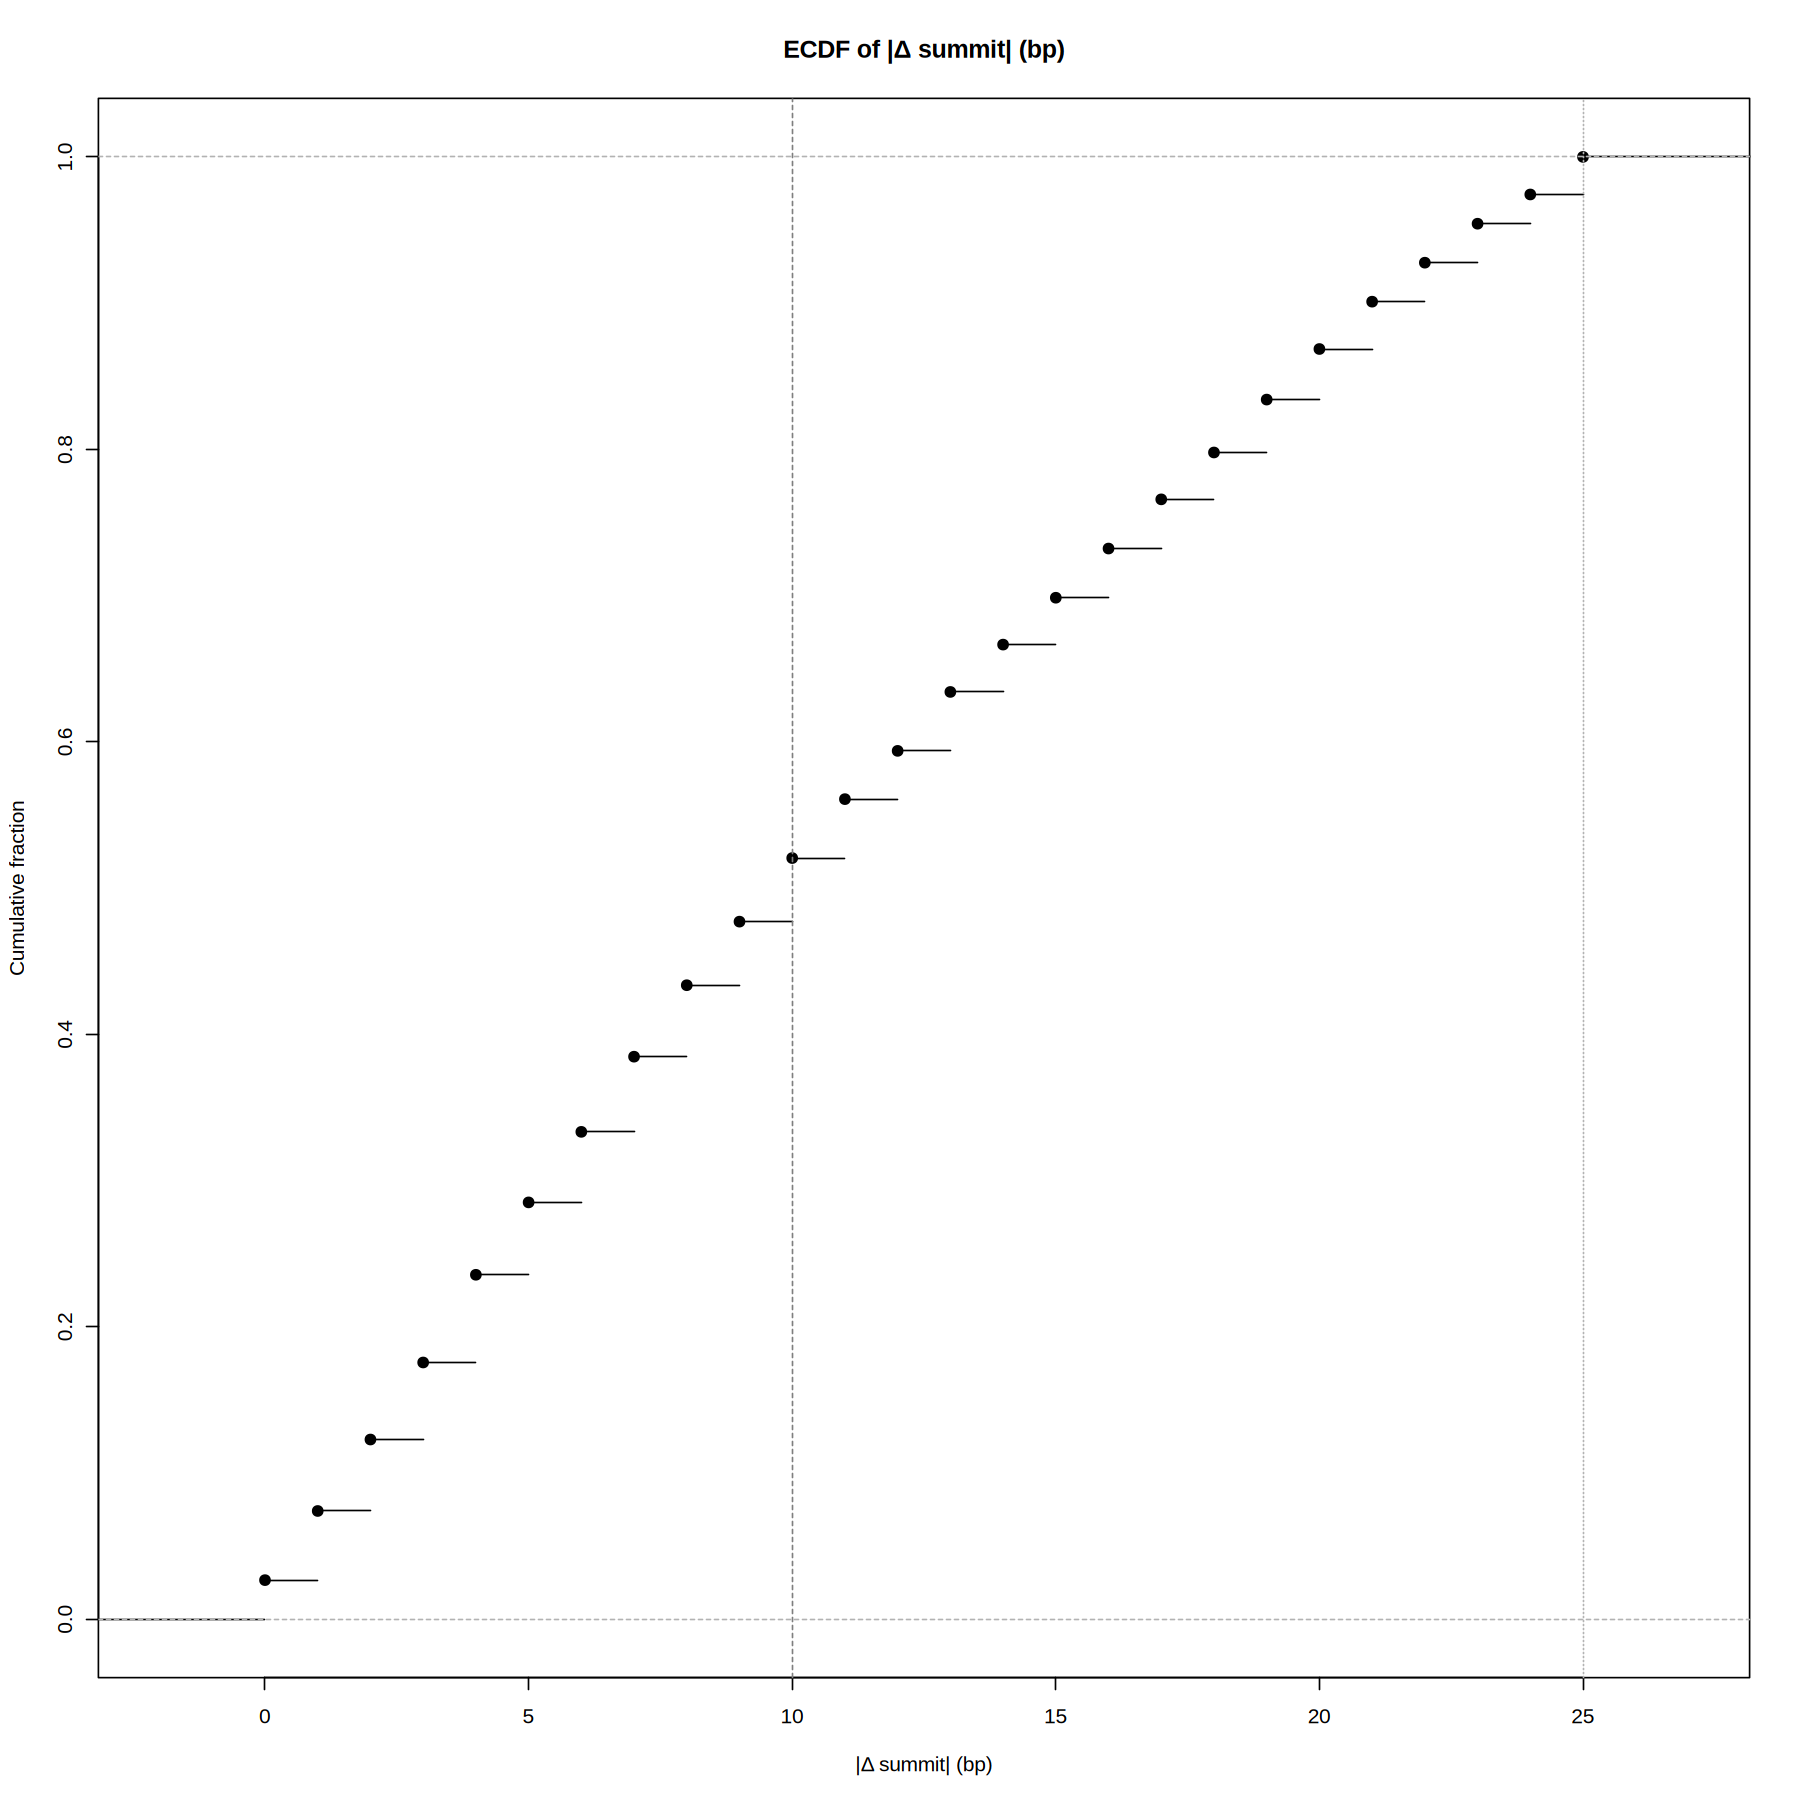

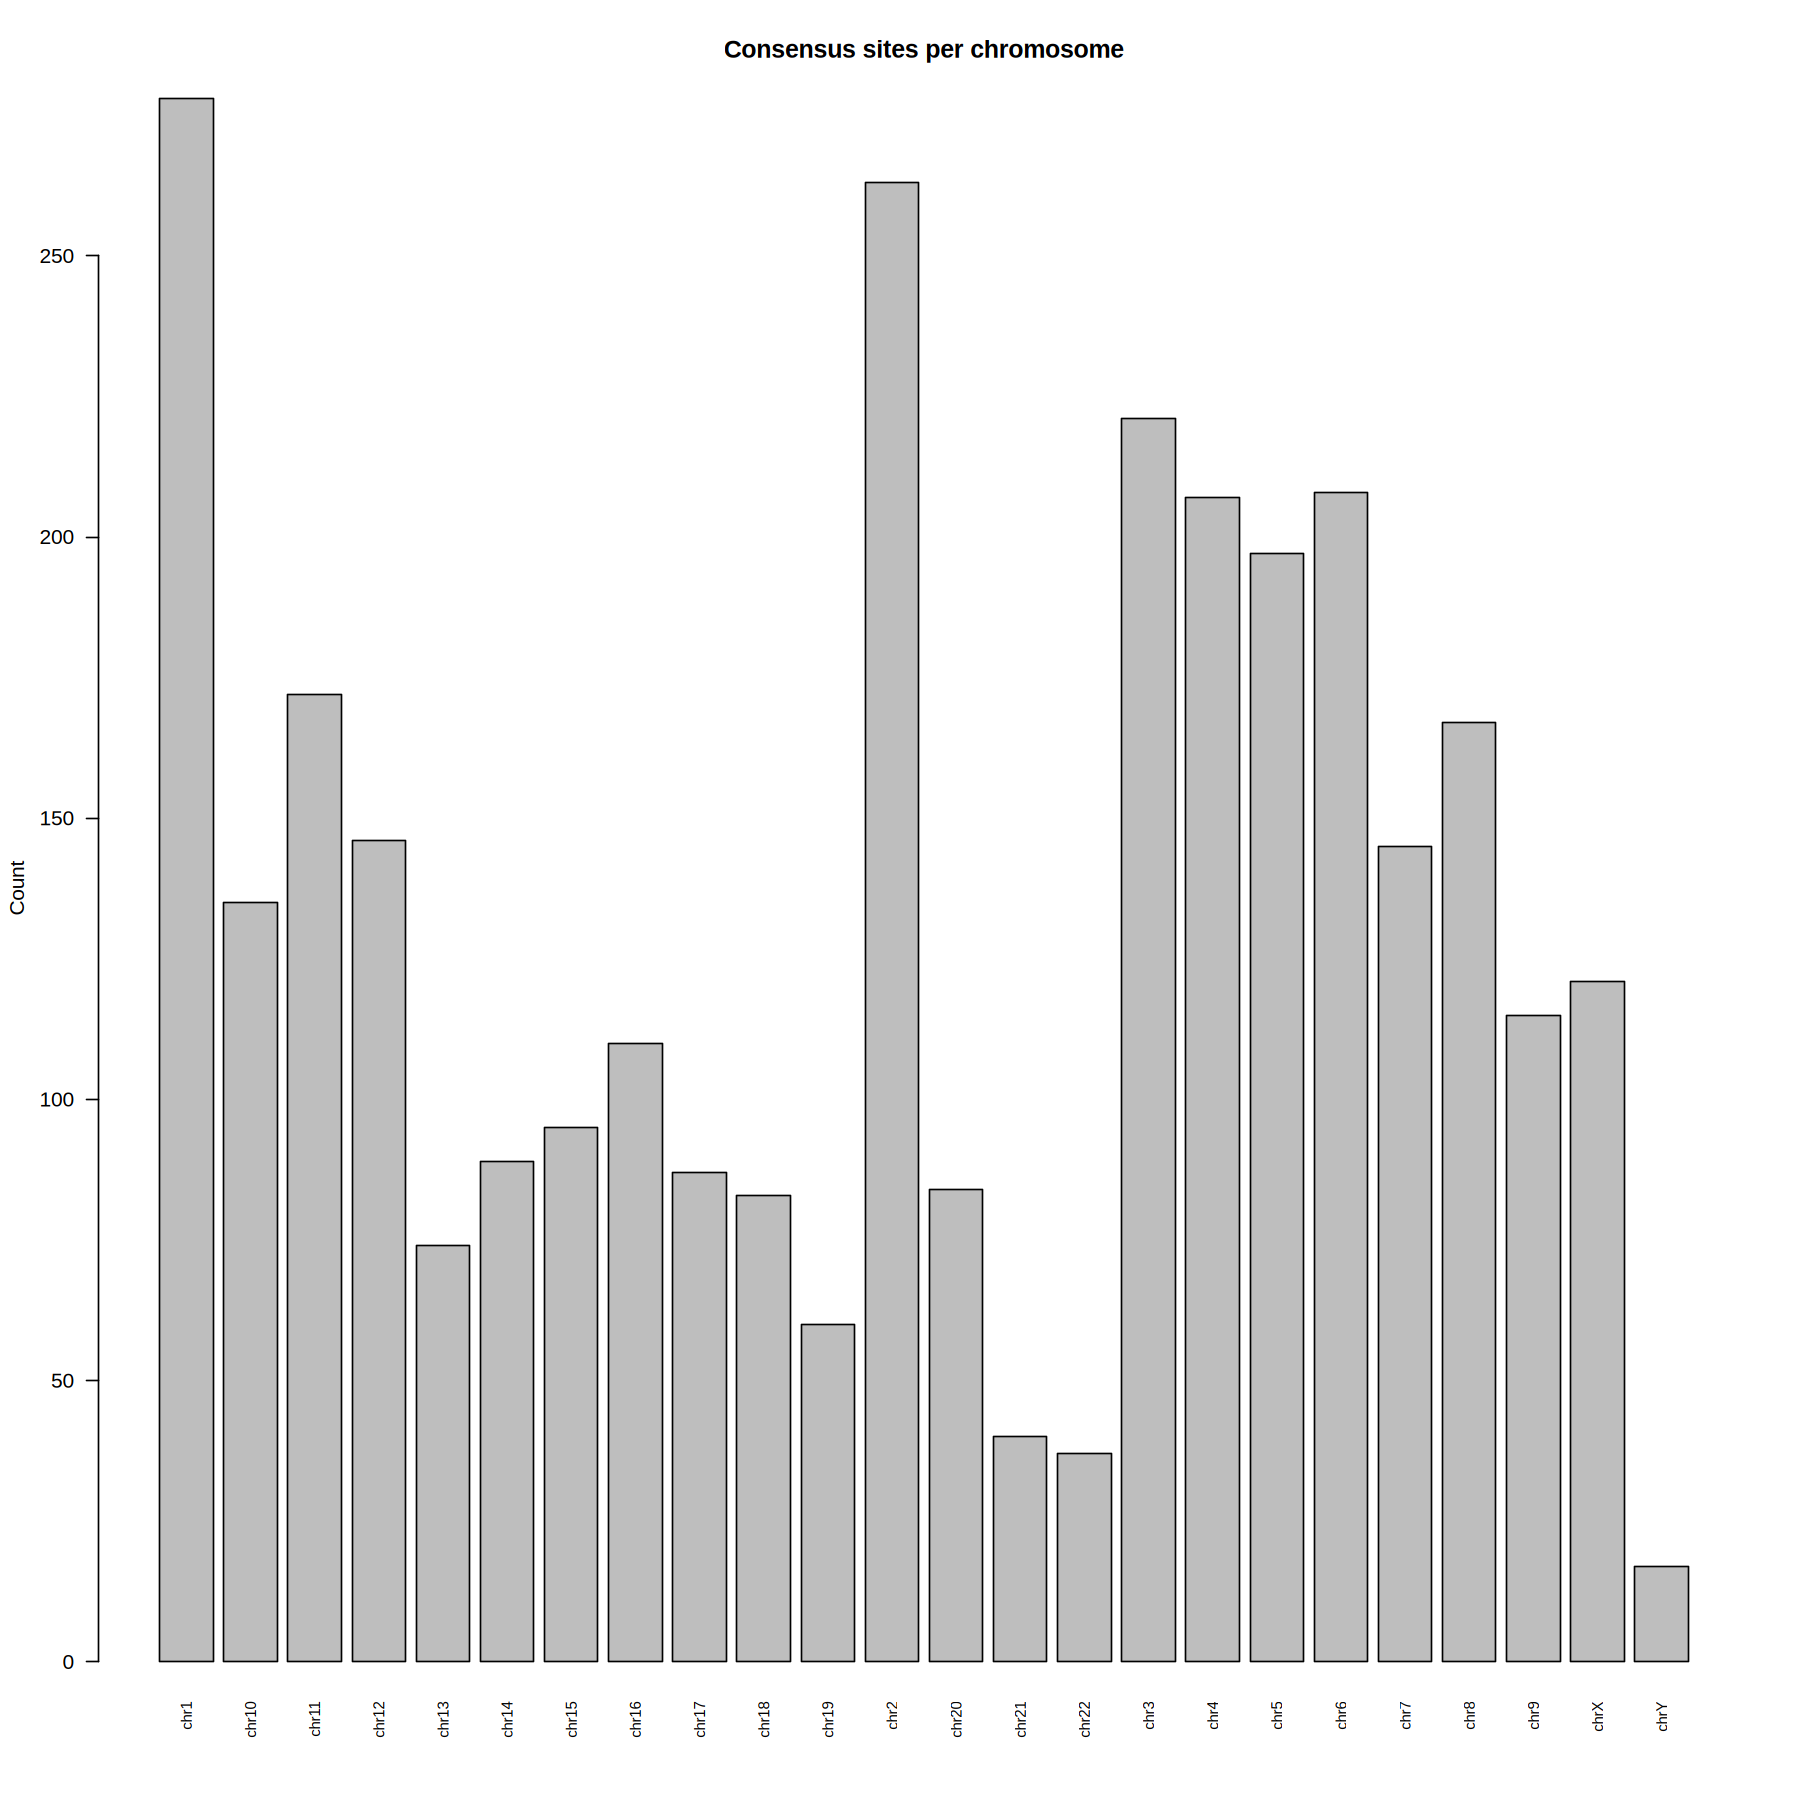

In [26]:
plot(ecdf(mcols(gr)$summit_delta),
     main = "ECDF of |Δ summit| (bp)",
     xlab = "|Δ summit| (bp)", ylab = "Cumulative fraction")
abline(v = c(10, 25), col = c("grey50", "grey70"), lty = c(2, 3))

barplot(table(as.character(seqnames(gr))),
        las = 2, cex.names = 0.7, main = "Consensus sites per chromosome",
        ylab = "Count")
as.data.frame(gr[order(mcols(gr)$jaccard_index, decreasing=TRUE)][1:5,
           c("seqnames","start","end","jaccard_index","summit_delta")])
as.data.frame(gr[order(mcols(gr)$jaccard_index, decreasing=FALSE)][1:5,
           c("seqnames","start","end","jaccard_index","summit_delta")])


In [27]:
dup <- duplicated(gr)
cat(sprintf("Duplicated intervals: %d\n", sum(dup)))
# If needed:
# gr <- gr[!dup]


Duplicated intervals: 0
